<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 3

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [62]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [63]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx=" # handles pymc warning

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ValueWarning)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import torch
import seaborn as sns
import optuna
import pymc as pm
import arviz as az
import yfinance as yf
import itertools

from arch import arch_model
from IPython.display import display
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, WhiteKernel
from sklearn.datasets import fetch_openml
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [64]:
random_state = 333

## Table of Contents

* [Problem 2.1: Bayesian Linear Regression](#problem-31-bayesian-linear-regression)
* [Problem 2.2: Gaussian Process Regression](#problem-32-guassian-process-regression)
* [Problem 2.3: ARIMA Modeling](#problem-33-arima-modeling)
* [Problem 2.4: GARCH for Volatility](#problem-34-garch-for-volatility)

## Problem 3.1: Bayesian Linear Regression

### Objective
Implement Bayesian linear regression using PyMC

### Tasks
- Use a polynomial regression problem with noisy data (use synthetic data
or Advertising Dataset from Kaggle).
- Set appropriate priors for coefficients and noise.
- Sample from the posterior using MCMC.
- Visualize posterior distributions and credible intervals.
- Compare with standard maximum likelihood estimation

We will start with generating the data which follows the formula

$Y_i \sim N(\mu_i,\sigma)$, $\mu_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2$

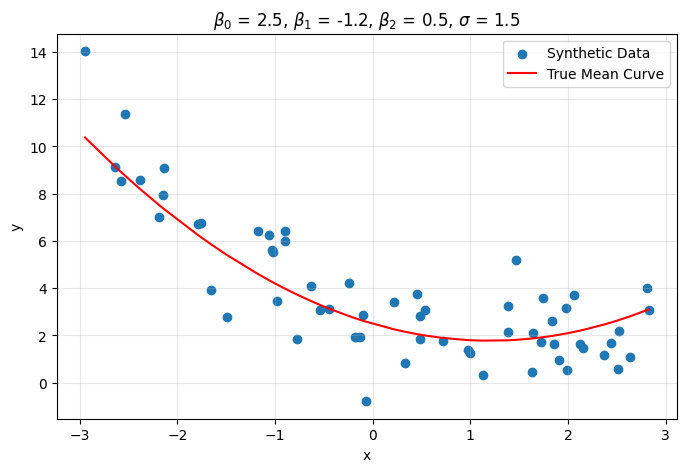

In [65]:
rng = np.random.default_rng(random_state)

n_samples = 60
true_beta_0 = 2.5
true_beta_1 = -1.2
true_beta_2 = 0.5
true_sigma = 1.5

x = np.sort(rng.uniform(-3, 3, n_samples))
true_mu = true_beta_0 + true_beta_1 * x + true_beta_2 * (x**2)
y = rng.normal(true_mu, true_sigma)

plt.figure(figsize=(8, 5))
plt.title(fr"$\beta_0$ = {true_beta_0}, $\beta_1$ = {true_beta_1}, $\beta_2$ = {true_beta_2}, $\sigma$ = {true_sigma}")
plt.scatter(x, y, label="Synthetic Data")
plt.plot(x, true_mu, color="red", label="True Mean Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now, before building the Bayesian model, we calculate the standard MLE parameters to serve as a baseline for comparison.

MLE Beta 0: 2.64
MLE Beta 1: -1.42
MLE Beta 2: 0.53


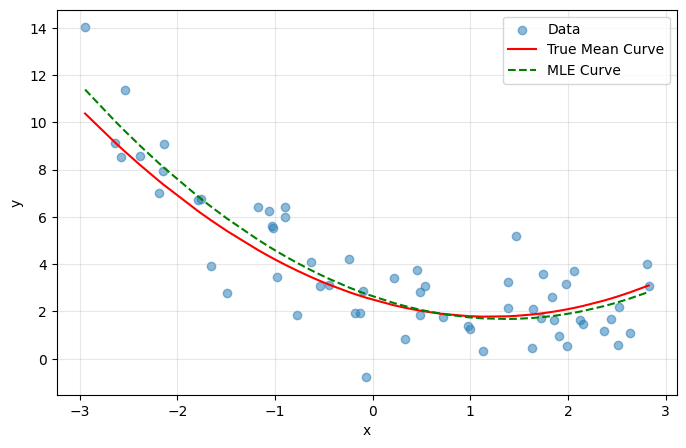

In [66]:
mle_coeffs = np.polyfit(x, y, 2)
mle_beta_2, mle_beta_1, mle_beta_0 = mle_coeffs

mle_mu = mle_beta_0 + mle_beta_1 * x + mle_beta_2 * (x**2)

print(f"MLE Beta 0: {mle_beta_0:.2f}")
print(f"MLE Beta 1: {mle_beta_1:.2f}")
print(f"MLE Beta 2: {mle_beta_2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(x, true_mu, color="red", label="True Mean Curve")
plt.plot(x, mle_mu, color="green", linestyle="--", label="MLE Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

We can see that the MLE curve is very close to the true mean curve. However, it is slightly above the original line for the lower values of x, and below it for the higher arguments.

At this stage, we can define the Bayesian model using PyMC. We assign weakly informative Normal priors for the coefficients $\beta$ and a Half-Normal prior for the standard deviation $\sigma$. We can sample the prior and plot prior predictive check. The prior predictive check plot visualizes what kinds of datasets model thinks are possible based strictly on the priors, before it has ever seen true values.

In [67]:
with pm.Model() as poly_model:
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=10)
    beta_2 = pm.Normal("beta_2", mu=0, sigma=10)
    
    sigma = pm.HalfNormal("sigma", sigma=5)
    
    mu = beta_0 + beta_1 * x + beta_2 * (x**2)
    
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=y)
    
    prior_predictive = pm.sample_prior_predictive(random_seed=random_state)
    
    trace = pm.sample(2000, tune=1000, chains=4, return_inferencedata=True, random_seed=random_state)

Sampling: [Y_obs, beta_0, beta_1, beta_2, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1, beta_2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 74 seconds.


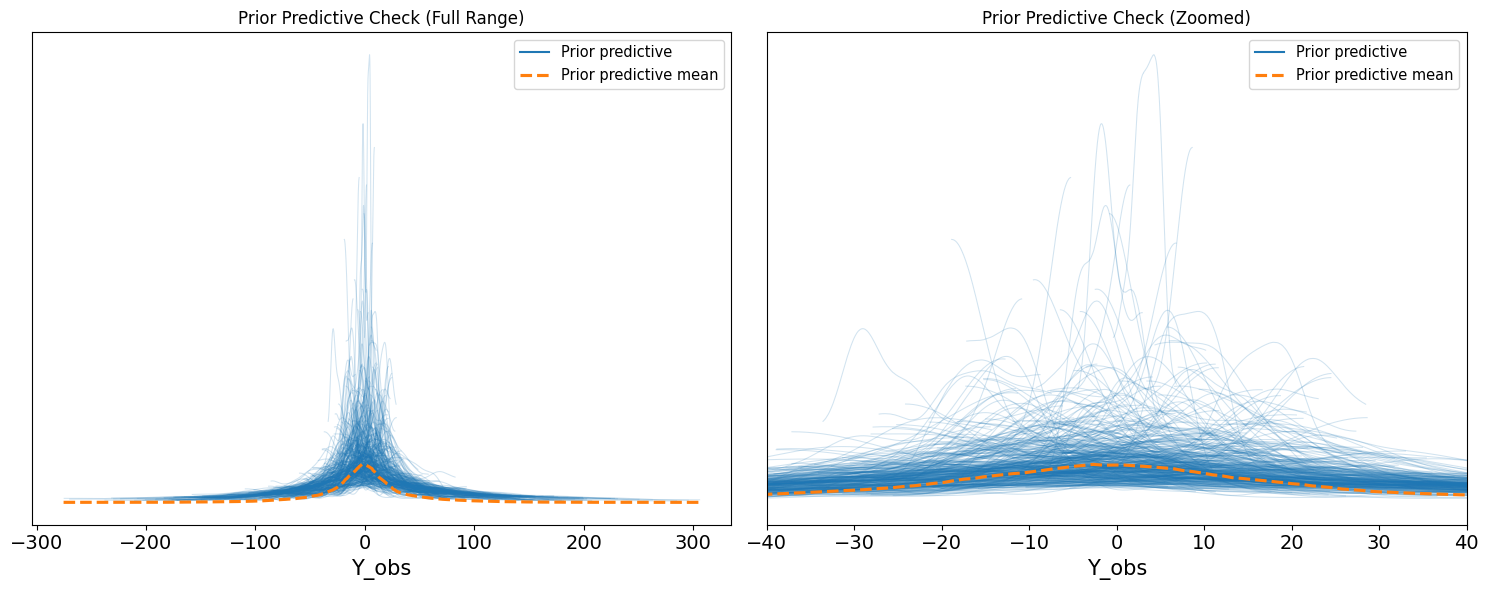

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
az.plot_ppc(prior_predictive, group="prior", ax=axes[0])
axes[0].set_title("Prior Predictive Check (Full Range)")

az.plot_ppc(prior_predictive, group="prior", ax=axes[1])
axes[1].set_title("Prior Predictive Check (Zoomed)")
axes[1].set_xlim(-40, 40)

plt.tight_layout()
plt.show()

On the plot, each blue line represents a single simulated dataset generated by randomly drawing $\beta$ and $\sigma$ values from the prior distributions. Our true data (which ranges between -1 and 14) falls right in the thickest part of thie distribution.

Now we use ArviZ to inspect the MCMC chains and visualize the posterior probability distributions for all parameters, highlighting the 94% credible intervals.

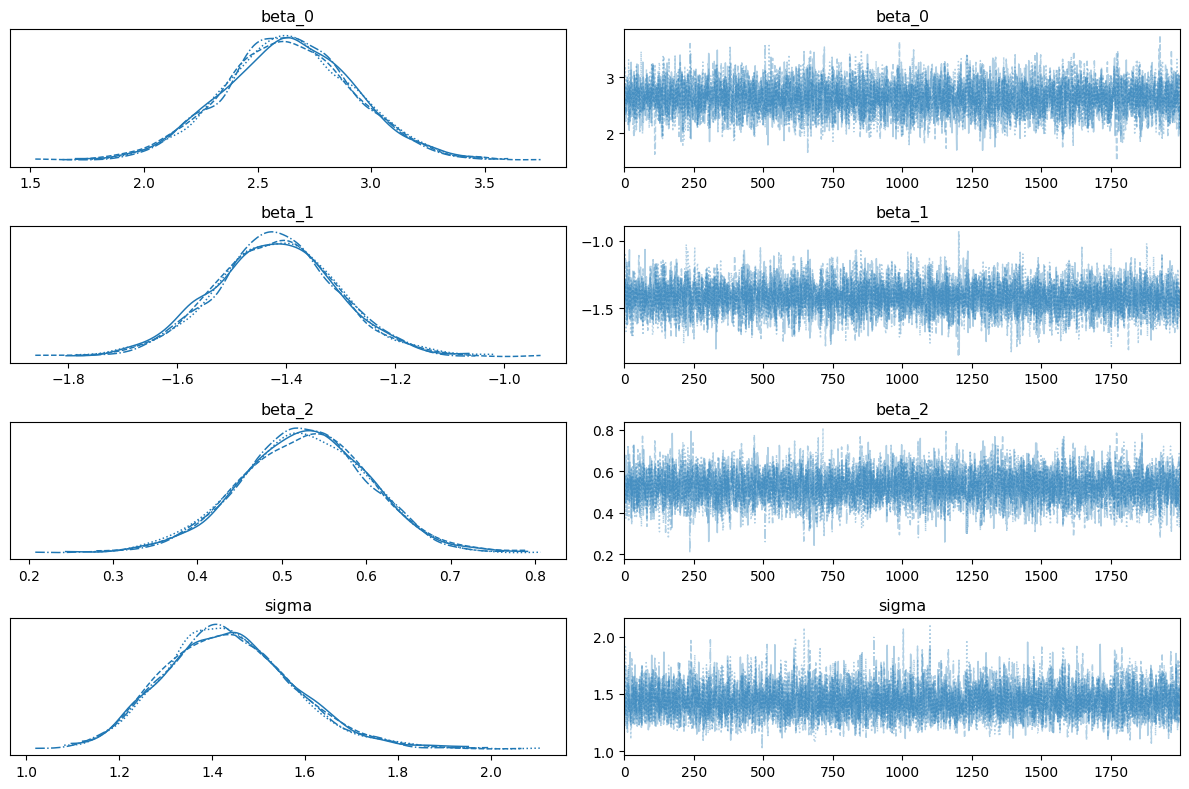

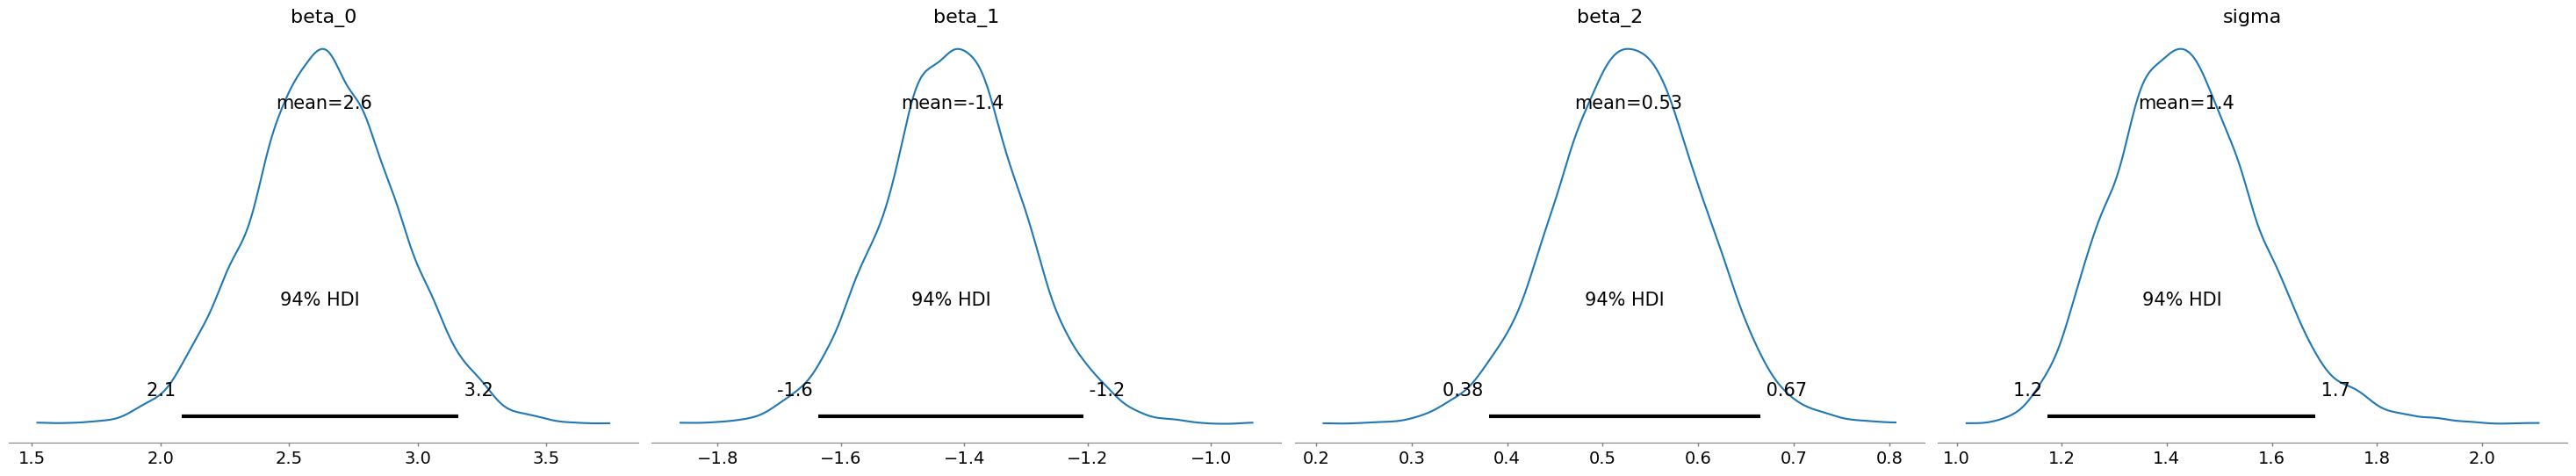

In [69]:
az.plot_trace(trace, var_names=["beta_0", "beta_1", "beta_2", "sigma"])
plt.tight_layout()
plt.show()

az.plot_posterior(trace, var_names=["beta_0", "beta_1", "beta_2", "sigma"], hdi_prob=0.94)
plt.tight_layout()
plt.show()

The left column of the trace plot contains Kernel Density Estimation plots. They represent the posterior probability distribution for each parameter. The multiple lines represent the different, independent Markov chains and all of them overlap almost perfectly for each parameter, which indicates the convergence. The plots on the right side show the sequential history of the values sampled by the MCMC algorithm across all iterations. The chains bounce rapidly and randomly around a central mean.

The posterior plot shows us the estimated parameters with the credential intervals. To get a comprehensive statistical breakdown, including the 94% HDI bounds, effective sample size, and R-hat convergence diagnostic, we can generate a summary table.

In [70]:
summary_df = az.summary(trace, var_names=["beta_0", "beta_1", "beta_2", "sigma"], hdi_prob=0.94)
print("Trace Summary and HDI Table:")
display(summary_df)

Trace Summary and HDI Table:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,2.635,0.285,2.083,3.157,0.004,0.003,5343.0,4779.0,1.0
beta_1,-1.420,0.114,-1.637,-1.208,0.001,0.001,6625.0,5119.0,1.0
beta_2,0.527,0.076,0.381,0.665,0.001,0.001,5637.0,5078.0,1.0
sigma,1.438,0.139,1.173,1.683,0.002,0.002,5817.0,4794.0,1.0


All $\hat{r}$ values are exactly 1.0, which means a perfect convergence. Effective Sample Size tells us how many truly independent samples we got. The values are massive, so the sampler navigated the geometry of the model with good efficiency. Highest Density Intervals include the true values for all the parameters. The Monte Carlo Standard Error values are very low, which is a result of high ESS values.

Now we can compare obtained mean values with MLE and true values.

In [71]:
post_beta_0 = float(trace.posterior["beta_0"].mean())
post_beta_1 = float(trace.posterior["beta_1"].mean())
post_beta_2 = float(trace.posterior["beta_2"].mean())
post_sigma = float(trace.posterior["sigma"].mean())

mle_residuals = y - mle_mu
mle_sigma = np.std(mle_residuals)

comparison_data = {
    "Parameter": ["beta_0", "beta_1", "beta_2", "sigma"],
    "True Value": [true_beta_0, true_beta_1, true_beta_2, true_sigma],
    "MLE Value": [mle_beta_0, mle_beta_1, mle_beta_2, mle_sigma],
    "Posterior Mean": [post_beta_0, post_beta_1, post_beta_2, post_sigma]
}

comparison_df = pd.DataFrame(comparison_data)

print("Parameter comparison:")
print(comparison_df.to_string(index=False))

Parameter comparison:
Parameter  True Value  MLE Value  Posterior Mean
   beta_0         2.5   2.641739        2.634937
   beta_1        -1.2  -1.420077       -1.420092
   beta_2         0.5   0.525857        0.526697
    sigma         1.5   1.374330        1.437666


All of the obtained posterior results are very close to the MLE values. The posterior mean was a slightly more accurate estimation of the $\sigma$ parameter.

We can extract the sampled parameters to reconstruct the estimated polynomial function. This allows us to calculate the posterior mean curve and the 94% highest density interval (HDI) for the expected value $\mu_i$​, comparing it directly against the MLE and the true underlying curve.

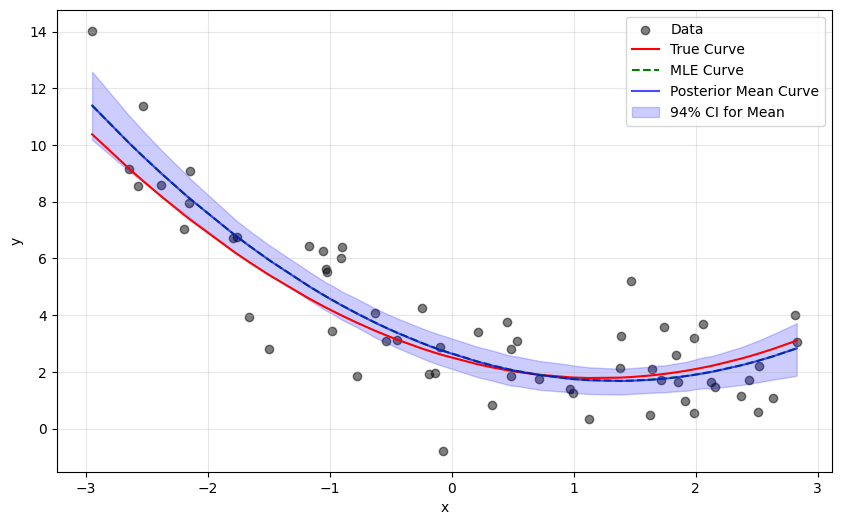

In [72]:
posterior = trace.posterior
beta_0_samples = posterior["beta_0"].values.flatten()
beta_1_samples = posterior["beta_1"].values.flatten()
beta_2_samples = posterior["beta_2"].values.flatten()

mu_samples = beta_0_samples[:, None] + beta_1_samples[:, None] * x + beta_2_samples[:, None] * (x**2)

mu_mean = mu_samples.mean(axis=0)
mu_hdi = az.hdi(mu_samples, hdi_prob=0.94)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, color="black", label="Data")
plt.plot(x, true_mu, color="red", label="True Curve")
plt.plot(x, mle_mu, color="green", linestyle="--", label="MLE Curve")
plt.plot(x, mu_mean, color="blue", label="Posterior Mean Curve", alpha = 0.7)

plt.fill_between(x, mu_hdi[:, 0], mu_hdi[:, 1], color="blue", alpha=0.2, label="94% CI for Mean")

plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The posterior mean curve and MLE curve almost perfectly overlap, being a close approximation of the original function.

Now we generate samples from the posterior predictive distribution. This accounts for both the uncertainty in the parameters and the inherent noise $\sigma$, providing the 94% credible interval for the actual observations $y_i$​.

Sampling: [Y_obs]


Output()

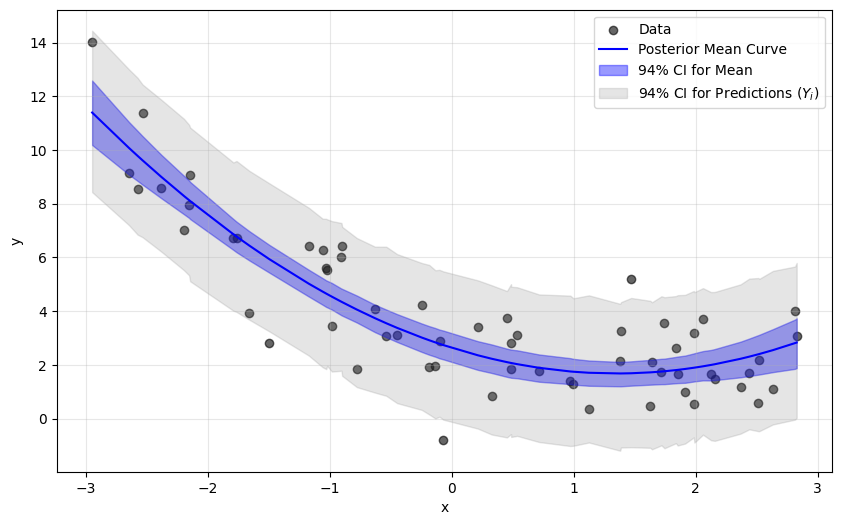

In [73]:
with poly_model:
    posterior_predictive = pm.sample_posterior_predictive(trace, random_seed=random_state)

y_pred_samples = posterior_predictive.posterior_predictive["Y_obs"]
y_hdi = az.hdi(y_pred_samples, hdi_prob=0.94).Y_obs.values

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, color="black", label="Data")
plt.plot(x, mu_mean, color="blue", label="Posterior Mean Curve")

plt.fill_between(x, mu_hdi[:, 0], mu_hdi[:, 1], color="blue", alpha=0.4, label="94% CI for Mean")
plt.fill_between(x, y_hdi[:, 0], y_hdi[:, 1], color="gray", alpha=0.2, label=fr"94% CI for Predictions ($Y_i$)")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In fact, there are only a few points that do not belong to the credible interval. Finally, we calculate the numerical coverage to see exactly what percentage of the actual observations fall within our 94% posterior predictive interval.

In [74]:
inside_interval = (y >= y_hdi[:, 0]) & (y <= y_hdi[:, 1])
coverage_count = inside_interval.sum()
total_points = len(y)
coverage_percentage = (coverage_count / total_points) * 100

print(f"Points inside the 94% predictive interval: {coverage_count} out of {total_points}")
print(f"Numerical coverage: {coverage_percentage:.2f}%")

Points inside the 94% predictive interval: 57 out of 60
Numerical coverage: 95.00%


We can see that exactly 95% of the points were covered by the 94% predictive interval, which is a solid result that confirms the accuracy of our estimations.

## Problem 3.2: Gaussian Process Regression

### Objective
Apply Gaussian Processes to function approximation

### Tasks
- Use GPyTorch or scikit-learn.
- Test on synthetic 1D and 2D functions.
- Use Mauna Loa CO2 dataset or temperature time series from your hometown
- Experiment with different kernels (RBF, Matern, Periodic).
- Visualize mean predictions and uncertainty bounds.
- Discuss computational complexity for large datasets.

We use the `scikit-learn` implementation of GPR.

### 1. Function approximation in 1D


We begin with a simple one-dimensional regression problem. The purpose of this experiment is to verify whether Gaussian Processes can reconstruct a smooth nonlinear function from a small number of noisy observations.

The chosen target function combines sine and cosine components, which makes it nonlinear but still easy to visualize.

In [67]:
def f_1d(x):
    return np.sin(x) + 0.3 * np.cos(2 * x)

X_train_1d = np.linspace(0, 10, 20).reshape(-1, 1)  
# reshape(-1, 1) converts the vector into a column format required by scikit-learn
y_train_1d = f_1d(X_train_1d).ravel() + np.random.normal(0, 0.2, X_train_1d.shape[0])  
# .ravel() flattens the array from shape (n, 1) to shape (n,)

X_test_1d = np.linspace(0, 10, 300).reshape(-1, 1)

Before fitting the model, it is useful to inspect the noisy training samples and compare them with the true underlying function.

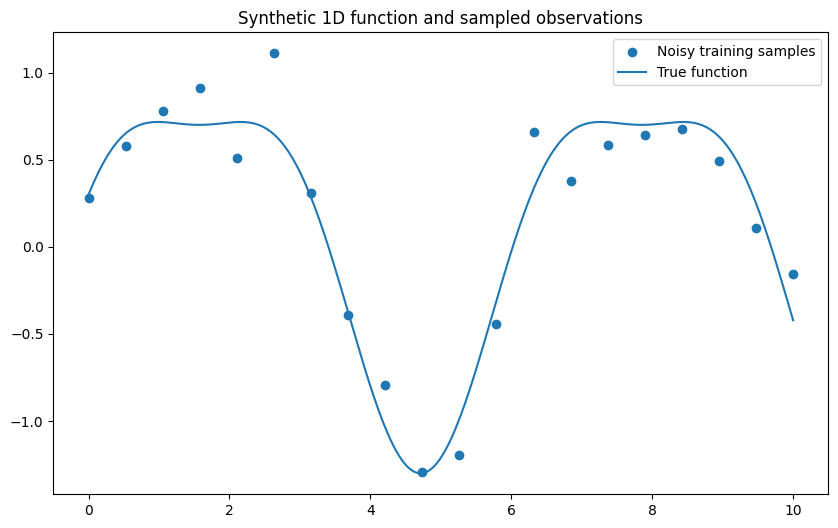

In [68]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_1d, y_train_1d, label="Noisy training samples")
plt.plot(X_test_1d, f_1d(X_test_1d), label="True function")
plt.title("Synthetic 1D function and sampled observations")
plt.legend()
plt.show()

The first experiment uses the RBF kernel, which assumes a smooth underlying function. A WhiteKernel component is added to explicitly model noise in the observations.

Gaussian Process returns:
- the mean prediction,
- the predictive standard deviation, which represents uncertainty.

In [69]:
kernel_rbf = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gpr_rbf_1d = GaussianProcessRegressor(kernel=kernel_rbf)
gpr_rbf_1d.fit(X_train_1d, y_train_1d)

y_pred_1d, y_std_1d = gpr_rbf_1d.predict(X_test_1d, return_std=True)
# return_std=True returns the standard deviation for each prediction

and lets visualize it

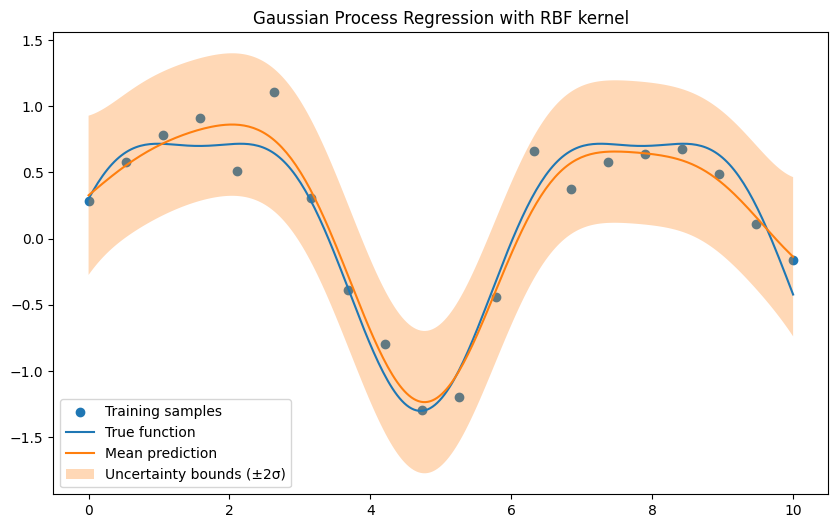

In [70]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_1d, y_train_1d, label="Training samples")
plt.plot(X_test_1d, f_1d(X_test_1d), label="True function")
plt.plot(X_test_1d, y_pred_1d, label="Mean prediction")

plt.fill_between(
    X_test_1d.ravel(),  
    # .ravel() converts X values to 1D, which is required by fill_between
    y_pred_1d - 2 * y_std_1d,
    y_pred_1d + 2 * y_std_1d,
    alpha=0.3,
    label="Uncertainty bounds (±2σ)"
)

plt.title("Gaussian Process Regression with RBF kernel")
plt.legend()
plt.show()

The Gaussian Process with the RBF kernel reconstructs the overall shape of the target function reasonably well. The predicted mean follows the nonlinear trend of the data, although some differences can be seen in the central point, where the model produces a smoother approximation than the true function.

The uncertainty band is relatively wide, which is expected because the model was trained on a small number of noisy observations. At the same time, the uncertainty remains lower near training samples and increases in regions where the local behavior of the function is harder to infer.

Overall, the result confirms that Gaussian Processes are well suited for smooth nonlinear regression tasks and provide useful uncertainty estimates together with predictions.

### 2. Comparison of Different Kernels in 1D

The choice of kernel has a major impact on the behavior of a Gaussian Process. We compare three kernels
- **RBF**, produces very smooth functions
- **Matern**: allows less smooth, more flexible behavior
- **Periodic**: is designed for repeating patterns.

In [71]:
kernels_1d = {
    "RBF": RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1),
    "Matern": Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=0.1),
    "Periodic": ExpSineSquared(length_scale=1.0, periodicity=3.0) + WhiteKernel(noise_level=0.1)
}

Each kernel is fitted separately.  

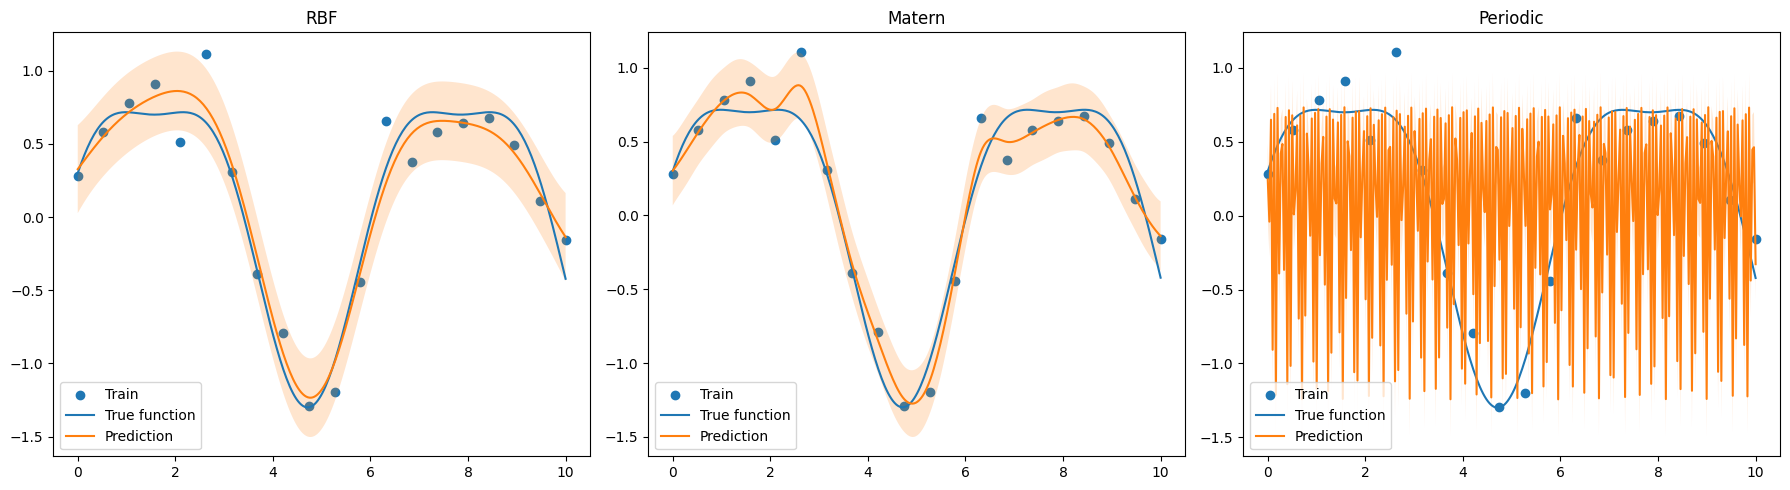

In [72]:
plt.figure(figsize=(18, 5))

for i, (kernel_name, kernel) in enumerate(kernels_1d.items(), start=1):
    gpr_model = GaussianProcessRegressor(kernel=kernel)
    gpr_model.fit(X_train_1d, y_train_1d)

    y_pred_kernel, y_std_kernel = gpr_model.predict(X_test_1d, return_std=True)

    plt.subplot(1, 3, i)
    plt.scatter(X_train_1d, y_train_1d, label="Train")
    plt.plot(X_test_1d, f_1d(X_test_1d), label="True function")
    plt.plot(X_test_1d, y_pred_kernel, label="Prediction")

    plt.fill_between(
        X_test_1d.ravel(),
        y_pred_kernel - y_std_kernel,
        y_pred_kernel + y_std_kernel,
        alpha=0.2
    )

    plt.title(kernel_name)
    plt.legend()

plt.tight_layout()
plt.show()

**The RBF and Matern kernels both produce reasonable approximations** of the target function. In both cases, the predicted curve follows the general nonlinear structure of the data and remains consistent with the training samples.

RBF kernel gives the smoothest approximation, which is visible especially around the central minimum and the right-hand peak. The Matern kernel produces a very similar result, but it is slightly more flexible and can better adapt to local changes in the function.

In contrast, **the Periodic kernel performs very poorly**. Instead of capturing the true trend, it generates strong oscillations that do not correspond to the underlying function. This happens because the synthetic target is not truly periodic, so the assumptions of the Periodic kernel are not appropriate for this problem.

Therefore, for this dataset, the RBF and Matern kernels are clearly more suitable than the Periodic kernel.

### 3. Gaussian Process Regression on a Synthetic 2D Function

After the one-dimensional example, the model is extended to two input dimensions. The selected function combines sine and cosine terms in two coordinates, producing a structured response surface. Random 2D points are sampled from a square domain.  

In [73]:
def f_2d(X):
    return np.sin(X[:, 0]) + np.cos(X[:, 1])
    # X[:, 0] selects the first feature
    # X[:, 1] selects the second feature

X_train_2d = np.random.uniform(0, 5, (100, 2))
y_train_2d = f_2d(X_train_2d) + np.random.normal(0, 0.1, 100)

for simplicity, an RBF kernel is used again

In [74]:
kernel_2d = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gpr_2d = GaussianProcessRegressor(kernel=kernel_2d)
gpr_2d.fit(X_train_2d, y_train_2d)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",RBF(length_sc...ise_level=0.1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

to visualize the model, a regular grid is constructed over the input space

In [75]:
grid_x, grid_y = np.meshgrid(
    np.linspace(0, 5, 60),
    np.linspace(0, 5, 60)
)

X_test_2d = np.column_stack([grid_x.ravel(), grid_y.ravel()])
# .ravel() flattens each grid into a 1D vector
# np.column_stack combines both vectors into shape (n_points, 2)

y_pred_2d, y_std_2d = gpr_2d.predict(X_test_2d, return_std=True)

The contour plot below presents the predicted mean values over the 2D input space.

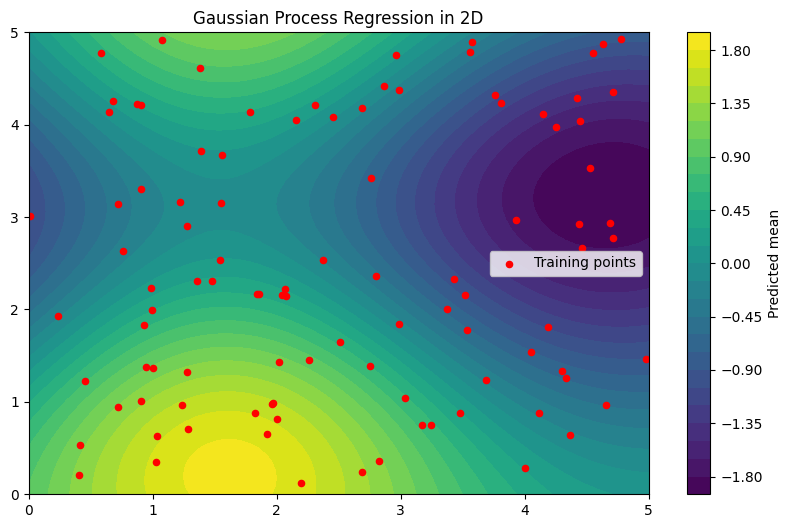

In [76]:
plt.figure(figsize=(10, 6))
plt.contourf(grid_x, grid_y, y_pred_2d.reshape(grid_x.shape), levels=30)
# reshape(grid_x.shape) restores the flat predictions back to the 2D grid shape

plt.colorbar(label="Predicted mean")
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c="red", s=20, label="Training points")
plt.title("Gaussian Process Regression in 2D")
plt.legend()
plt.show()

The next plot presents the predictive standard deviation over the 2D input space. Lower values indicate regions where the model is more confident, while higher values indicate regions where predictions are less certain.

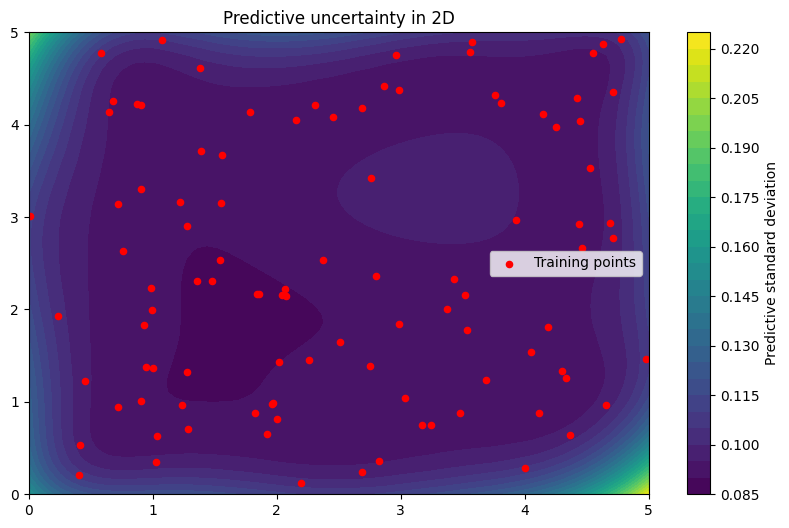

In [77]:
plt.figure(figsize=(10, 6))
plt.contourf(grid_x, grid_y, y_std_2d.reshape(grid_x.shape), levels=30)
plt.colorbar(label="Predictive standard deviation")
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c="red", s=20, label="Training points")
plt.title("Predictive uncertainty in 2D")
plt.legend()
plt.show()

The 2D **Gaussian Process successfully captures the global structure** of the target surface. The predicted mean shows smooth transitions across the input space and reflects the nonlinear combination of sine and cosine components.

The uncertainty plot is also consistent with expectations. The predictive standard deviation is generally lower in regions where training samples are dense and increases near the boundaries of the domain, where fewer observations support the prediction.

This behavior confirms one of the main advantages of Gaussian Processes: in addition to fitting complex nonlinear relationships, they also provide spatial information about how confident the model is in different regions of the input space.

### 4. Mauna Loa CO2

In this section, Gaussian Process Regression is applied to a real-world time series dataset. The dataset contains atmospheric CO2 measurements collected at the Mauna Loa Observatory.

In [78]:
df_co2 = pd.read_csv('./../datasets/co2_mm_mlo.csv')
df_co2.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


The dataset contains missing values marked with negative placeholders such as -9.99 and -1. Before applying Gaussian Processes, these values must be removed.

In [79]:
df_co2_clean = df_co2.copy()
df_co2_clean = df_co2_clean[df_co2_clean['average'] > 0]
df_co2_clean = df_co2_clean.reset_index(drop=True)
df_co2_clean.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


Gaussian Processes require numerical input features. Instead of using separate year and month columns, the "decimal date" feature is used, which represents time as a continuous variable.

**BUT!!!!** Gaussian Processes are sensitive to the scale of input features because the kernel operates on distances between points. The "decimal date" feature contains large values (around 2000), which can lead to numerical instability when computing the covariance matrix. To improve numerical stability, the time variable is shifted so that it starts at zero:

In [80]:
X_co2 = df_co2_clean['decimal date'].values.reshape(-1, 1)
# rescale time to start at zero for numerical stability
X_co2 = X_co2 - X_co2.min()


# reshape to (n_samples, 1) for scikit-learn
y_co2 = df_co2_clean['average'].values

lets see the data

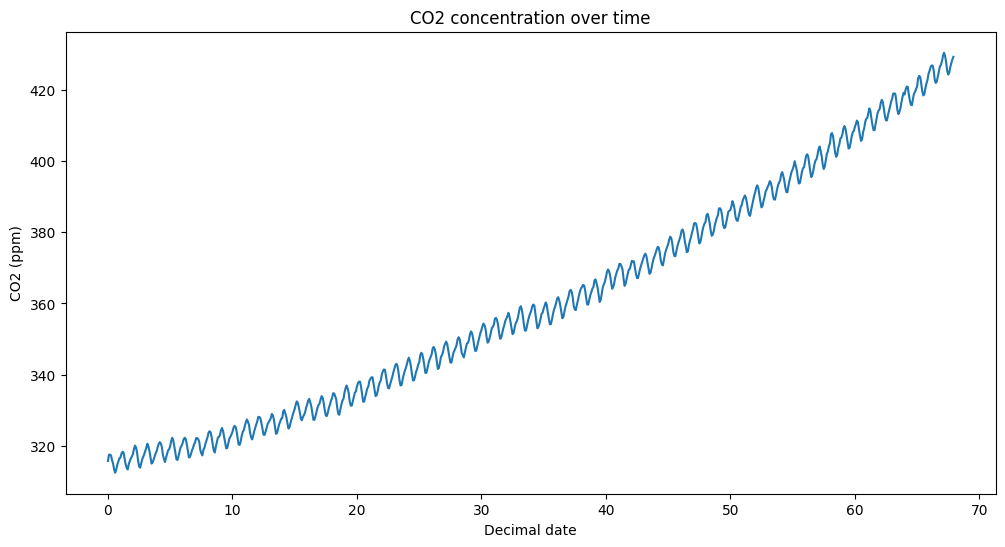

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(X_co2, y_co2)
plt.title("CO2 concentration over time")
plt.xlabel("Decimal date")
plt.ylabel("CO2 (ppm)")
plt.show()

The CO2 time series exhibits two dominant patterns:
- a smooth long-term upward trend,
- regular seasonal oscillations with a period of approximately one year.

To evaluate Gaussian Process Regression properly, the dataset should not be fitted and evaluated on the same observations. Therefore, the data are split according to time:
- observations up to the end of 2015 are used as the training set,
- observations after 2015 are used as the test set.

The model is then evaluated on the test set using RMSE, MAE and the percentage of test observations that fall inside the uncertainty bounds.

In [82]:
# keep original decimal dates for plotting and splitting
X_co2_decimal = df_co2_clean['decimal date'].values
y_co2 = df_co2_clean['average'].values

train_mask_co2 = X_co2_decimal <= 2015.999
test_mask_co2 = X_co2_decimal > 2015.999

X_train_co2_decimal = X_co2_decimal[train_mask_co2]
X_test_co2_decimal = X_co2_decimal[test_mask_co2]

y_train_co2 = y_co2[train_mask_co2]
y_test_co2 = y_co2[test_mask_co2]

# rescale time to start at zero for numerical stability
co2_time_origin = X_train_co2_decimal.min()

X_train_co2 = (X_train_co2_decimal - co2_time_origin).reshape(-1, 1)
X_test_co2 = (X_test_co2_decimal - co2_time_origin).reshape(-1, 1)

print(f"Number of training observations: {len(X_train_co2)}")
print(f"Number of test observations: {len(X_test_co2)}")
print(f"Training period: {X_train_co2_decimal.min():.2f} - {X_train_co2_decimal.max():.2f}")
print(f"Test period: {X_test_co2_decimal.min():.2f} - {X_test_co2_decimal.max():.2f}")

Number of training observations: 694
Number of test observations: 122
Training period: 1958.20 - 2015.96
Test period: 2016.04 - 2026.12


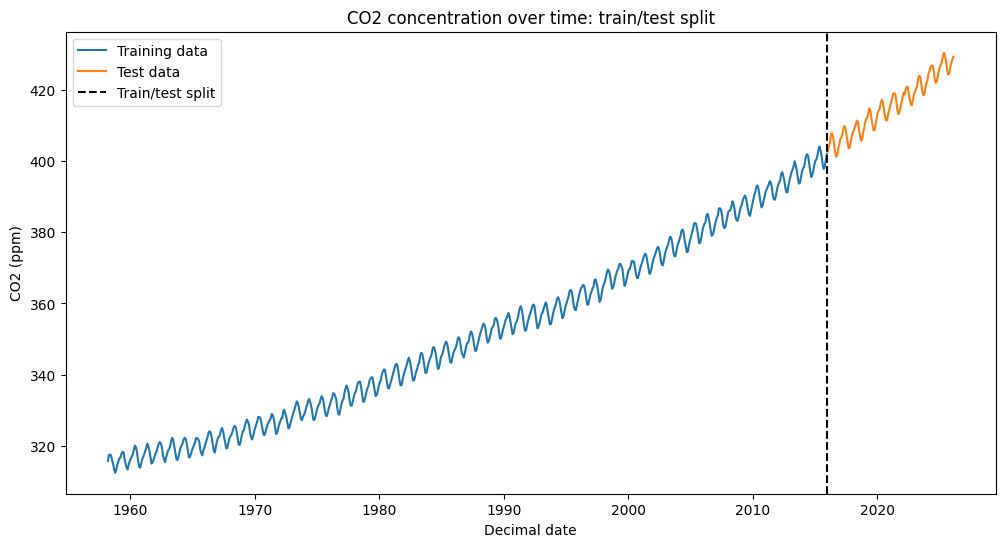

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(X_train_co2_decimal, y_train_co2, label="Training data")
plt.plot(X_test_co2_decimal, y_test_co2, label="Test data")
plt.axvline(2016, linestyle="--", color="black", label="Train/test split")
plt.title("CO2 concentration over time: train/test split")
plt.xlabel("Decimal date")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()

A suitable kernel for this dataset should account for both the long-term trend and the seasonal component.  

The first model uses:
- an RBF kernel for the smooth long-term trend,
- an ExpSineSquared kernel for yearly seasonality,
- a WhiteKernel for observation noise.

The second model replaces the RBF component with a Matern kernel, which allows less smooth functions and gives a useful comparison against the RBF-based model.

In [84]:
kernel_co2_rbf = (
    RBF(length_scale=10.0, length_scale_bounds=(1.0, 50.0)) +
    ExpSineSquared(
        length_scale=1.0,
        periodicity=1.0,
        length_scale_bounds=(0.1, 5.0),
        periodicity_bounds=(0.8, 1.2)
    ) +
    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 2.0))
)

kernel_co2_matern = (
    Matern(length_scale=10.0, length_scale_bounds=(1.0, 50.0), nu=1.5) +
    ExpSineSquared(
        length_scale=1.0,
        periodicity=1.0,
        length_scale_bounds=(0.1, 5.0),
        periodicity_bounds=(0.8, 1.2)
    ) +
    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 2.0))
)

co2_kernels = {
    "RBF + Periodic + White": kernel_co2_rbf,
    "Matern + Periodic + White": kernel_co2_matern
}

In [85]:
co2_results = []
co2_models = {}

for kernel_name, kernel in co2_kernels.items():
    gpr_co2 = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=random_state
    )
    
    gpr_co2.fit(X_train_co2, y_train_co2)
    
    y_pred_test_co2, y_std_test_co2 = gpr_co2.predict(X_test_co2, return_std=True)
    
    lower_test_co2 = y_pred_test_co2 - 2 * y_std_test_co2
    upper_test_co2 = y_pred_test_co2 + 2 * y_std_test_co2
    
    rmse = np.sqrt(np.mean((y_test_co2 - y_pred_test_co2) ** 2))
    mae = np.mean(np.abs(y_test_co2 - y_pred_test_co2))
    coverage = np.mean((y_test_co2 >= lower_test_co2) & (y_test_co2 <= upper_test_co2)) * 100
    
    co2_results.append({
        "Kernel": kernel_name,
        "RMSE": rmse,
        "MAE": mae,
        "Coverage inside ±2σ bounds (%)": coverage,
        "Learned kernel": gpr_co2.kernel_
    })
    
    co2_models[kernel_name] = {
        "model": gpr_co2,
        "y_pred_test": y_pred_test_co2,
        "y_std_test": y_std_test_co2,
        "lower_test": lower_test_co2,
        "upper_test": upper_test_co2
    }

co2_results_df = pd.DataFrame(co2_results)
co2_results_df

,Kernel,RMSE,MAE,Coverage inside ±2σ bounds (%),Learned kernel
0,RBF + Periodic + White,8.247624,6.275383,34.426230,RBF(length_scale=11) + ExpSineSquared(length_s...
1,Matern + Periodic + White,13.302888,9.921339,98.360656,"Matern(length_scale=16.4, nu=1.5) + ExpSineSqu..."


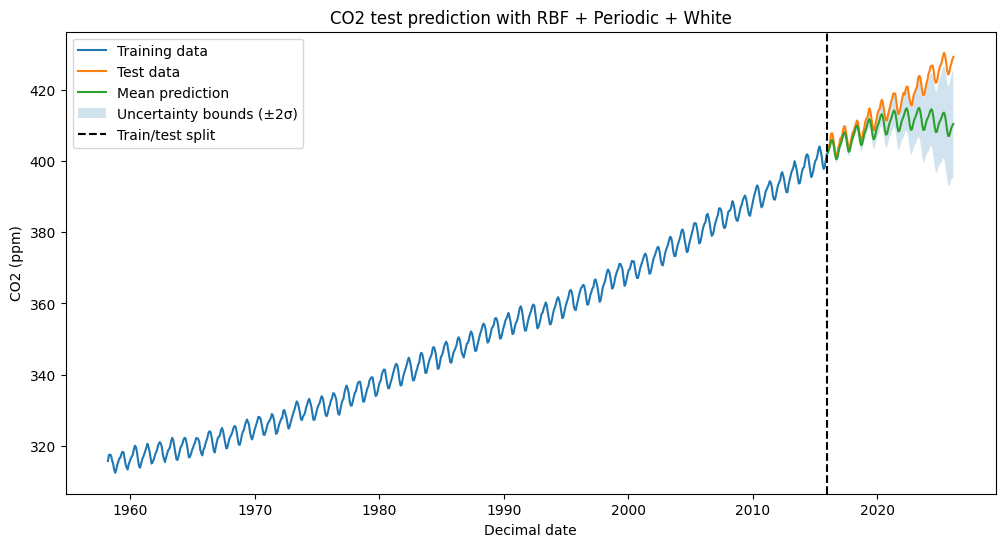

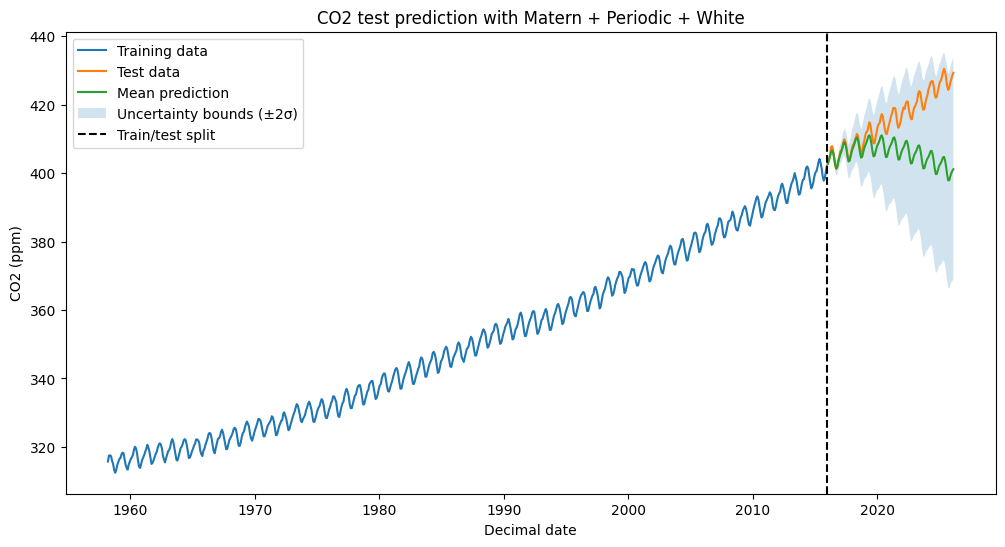

In [86]:
for kernel_name, model_data in co2_models.items():
    plt.figure(figsize=(12, 6))
    
    plt.plot(X_train_co2_decimal, y_train_co2, label="Training data")
    plt.plot(X_test_co2_decimal, y_test_co2, label="Test data")
    plt.plot(X_test_co2_decimal, model_data["y_pred_test"], label="Mean prediction")
    
    plt.fill_between(
        X_test_co2_decimal,
        model_data["lower_test"],
        model_data["upper_test"],
        alpha=0.2,
        label="Uncertainty bounds (±2σ)"
    )
    
    plt.axvline(2016, linestyle="--", color="black", label="Train/test split")
    plt.title(f"CO2 test prediction with {kernel_name}")
    plt.xlabel("Decimal date")
    plt.ylabel("CO2 (ppm)")
    plt.legend()
    plt.show()

The test-set evaluation gives a more realistic assessment than fitting the model on the full dataset and evaluating it on the same observations. RMSE and MAE measure the point prediction error, while the coverage percentage checks how many real test observations fall inside the predictive uncertainty bounds.

In [87]:
best_kernel_name = co2_results_df.sort_values("RMSE").iloc[0]["Kernel"]
best_gpr_co2 = co2_models[best_kernel_name]["model"]

print(f"Best kernel according to RMSE: {best_kernel_name}")
print(best_gpr_co2.kernel_)

Best kernel according to RMSE: RBF + Periodic + White
RBF(length_scale=11) + ExpSineSquared(length_scale=4.67, periodicity=1) + WhiteKernel(noise_level=0.000316)


Finally, the best model is used to generate predictions on a dense time grid from 1958 to 2050. This allows us to visualize:
- the fit on the training period,
- the forecast on the test period,
- the extrapolation beyond the observed dataset.

In [88]:
X_grid_co2_decimal = np.linspace(1958, 2050, 1200)
X_grid_co2 = (X_grid_co2_decimal - co2_time_origin).reshape(-1, 1)

y_pred_grid_co2, y_std_grid_co2 = best_gpr_co2.predict(X_grid_co2, return_std=True)

lower_grid_co2 = y_pred_grid_co2 - 2 * y_std_grid_co2
upper_grid_co2 = y_pred_grid_co2 + 2 * y_std_grid_co2

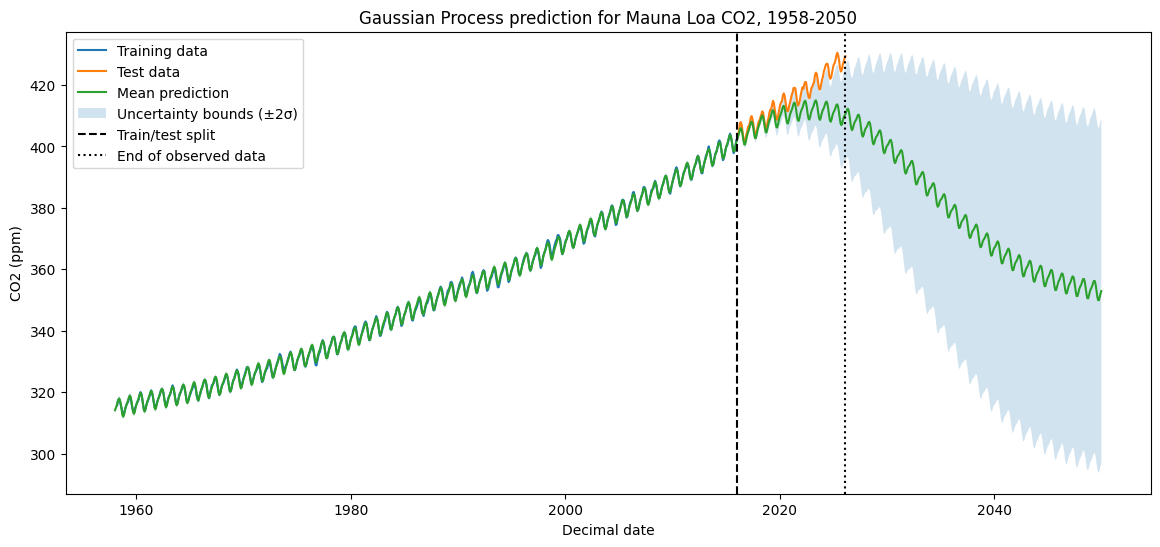

In [89]:
plt.figure(figsize=(14, 6))

plt.plot(X_train_co2_decimal, y_train_co2, label="Training data")
plt.plot(X_test_co2_decimal, y_test_co2, label="Test data")
plt.plot(X_grid_co2_decimal, y_pred_grid_co2, label="Mean prediction")

plt.fill_between(
    X_grid_co2_decimal,
    lower_grid_co2,
    upper_grid_co2,
    alpha=0.2,
    label="Uncertainty bounds (±2σ)"
)

plt.axvline(2016, linestyle="--", color="black", label="Train/test split")
plt.axvline(X_co2_decimal.max(), linestyle=":", color="black", label="End of observed data")

plt.title("Gaussian Process prediction for Mauna Loa CO2, 1958-2050")
plt.xlabel("Decimal date")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.show()

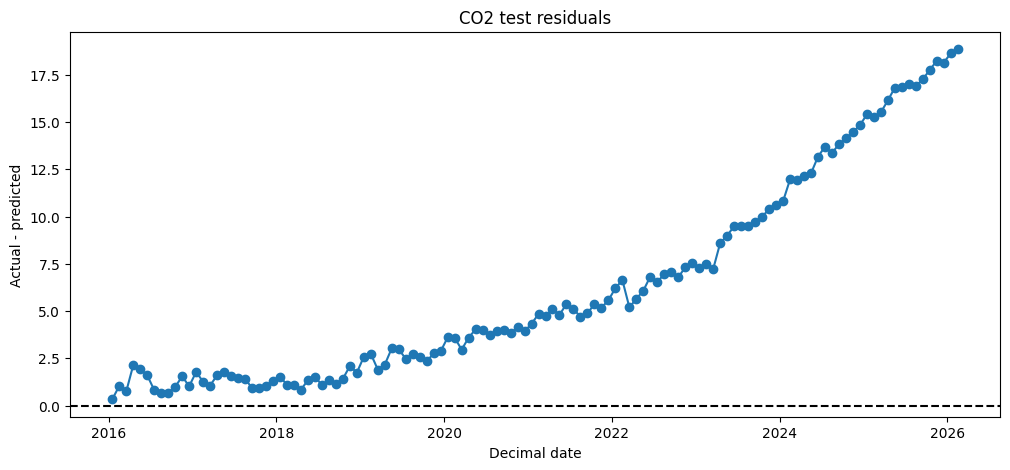

In [90]:
best_test_prediction = co2_models[best_kernel_name]["y_pred_test"]
test_residuals_co2 = y_test_co2 - best_test_prediction

plt.figure(figsize=(12, 5))
plt.plot(X_test_co2_decimal, test_residuals_co2, marker="o")
plt.axhline(0, linestyle="--", color="black")
plt.title("CO2 test residuals")
plt.xlabel("Decimal date")
plt.ylabel("Actual - predicted")
plt.show()

The residual plot shows a clear systematic upward drift. The residuals are positive and increase over time, which means that the GP predictions are increasingly below the actual CO2 values in the test period. Therefore, the model captures the seasonal oscillations reasonably well, but it does not extrapolate the long-term upward trend strongly enough after 2015.

The comparison of kernels also shows an important trade-off. The RBF + Periodic + White model gives the best point predictions with RMSE and MAE . However, only +-35% of test observations fall inside the +-2sigma uncertainty bounds. This means that the predictive intervals are too narrow and the model is overconfident. The Matern + Periodic + White model performs worse in terms of point prediction with RMSE and MAE, but it has much better uncertainty coverage.

### Computational complexity

For this dataset, the training set contains 694 monthly observations, so exact Gaussian Process Regression is still ok. The model can be fitted with `GaussianProcessRegressor`, although optimization becomes noticeably more expensive when several kernels and optimizer restarts are tested. the CO2 experiment also shows a modeling limitation rather than only a computational one. Even though the GP fits the historical training data well, extrapolation far beyond the observed range is difficult. The model learns smoothness and seasonality from the kernel, but it does not automatically know that atmospheric CO2 should keep increasing.

## Problem 3.3:  ARIMA Modelling

### Objective
Forecast stock prices using ARIMA.

### Tasks
- Download daily prices for any stock (2+ years of data).
- Check for stationarity using ADF test.
- Use ACF/PACF plots to determine ARIMA order.
- Fit ARIMA model and validate using last 20% of data.
- Generate 30-day forecast with confidence intervals.

Firstly, we will download Apple (AAPL) stock data covering a period of three years. We extract the closing prices, split the data into 80% training and 20% test sets, and visually inspect the training set for trends or changing variance.

[*********************100%***********************]  1 of 1 completed


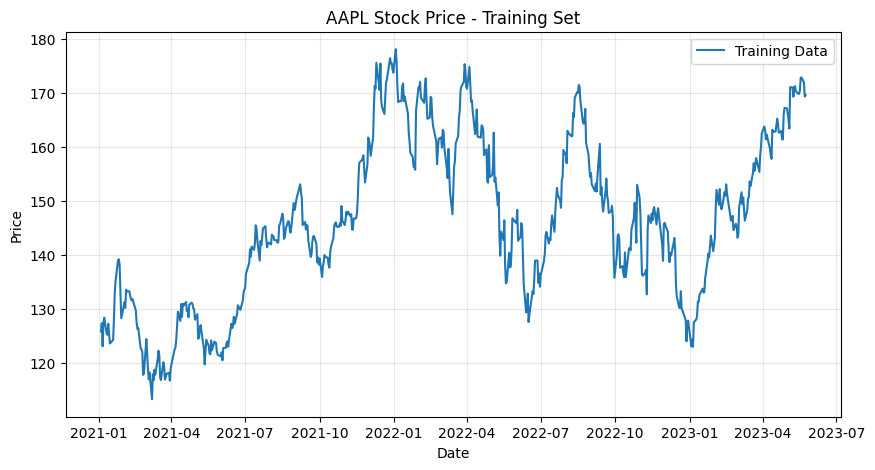

In [17]:
ticker = "AAPL"
data = yf.download(ticker, start="2021-01-01", end="2024-01-01")
prices = data['Close'].dropna()

if isinstance(prices, pd.DataFrame):
    prices = prices.squeeze()

train_size = int(len(prices) * 0.8)
train_data, test_data = prices.iloc[:train_size], prices.iloc[train_size:]

plt.figure(figsize=(10, 5))
plt.plot(train_data, label="Training Data")
plt.title(f"{ticker} Stock Price - Training Set")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

At the first glance it isn't looking like a stationary process.

That's why secondly, we use the ADF test to formally check for stationarity. If the p-value is greater than 0.05, we difference the data incrementally until it becomes stationary to find the optimal order of differencing (d).

Testing original training data:
ADF Statistic: -2.1205
p-value: 0.2363
Testing differenced data (d=1):
ADF Statistic: -18.7090
p-value: 0.0000
Optimal differencing order (d): 1


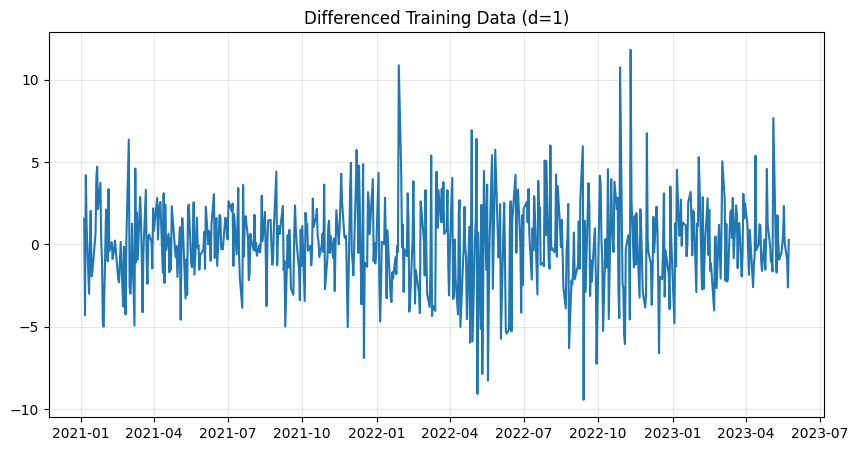

In [18]:
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    return result[1] <= 0.05

print("Testing original training data:")
is_stationary = check_stationarity(train_data)

d = 0
differenced_data = train_data.copy()

while not is_stationary and d < 3:
    d += 1
    differenced_data = differenced_data.diff().dropna()
    print(f"Testing differenced data (d={d}):")
    is_stationary = check_stationarity(differenced_data)

print(f"Optimal differencing order (d): {d}")

plt.figure(figsize=(10, 5))
plt.plot(differenced_data)
plt.title(f"Differenced Training Data (d={d})")
plt.grid(alpha=0.3)
plt.show()

Now it is looking like a stationary process. We can also check the ACF and PACF plots, which will help visually estimate the potential ranges for the autoregressive (p) and moving average (q) terms.

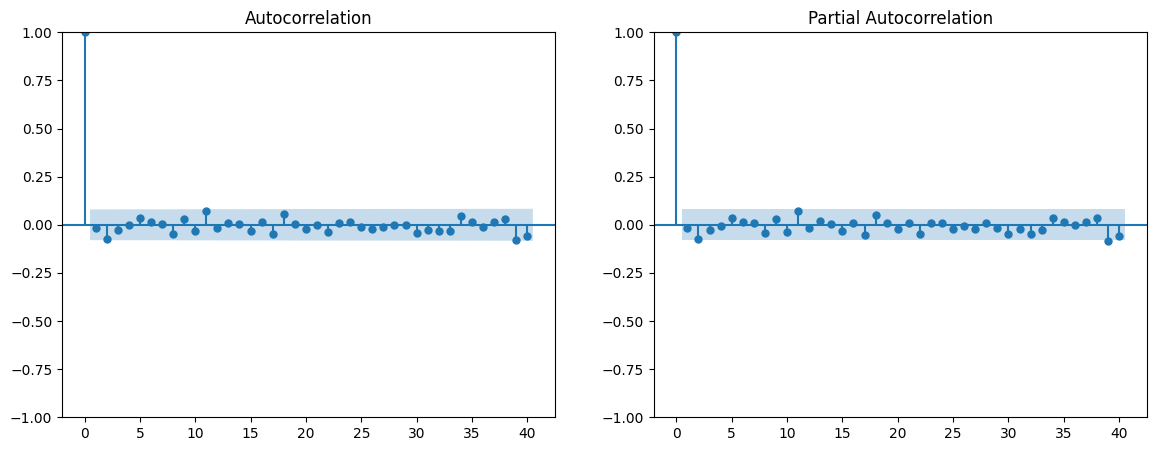

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(differenced_data, ax=axes[0], lags=40)
plot_pacf(differenced_data, ax=axes[1], lags=40)
plt.show()

There is no signifacnt autocorrelation nor partial autocorrelation in the dataset. We can assume that the dataset represents a random walk. However, to find the best parameters of the ARIMA model, we use the grid search approach.

In [14]:
p_values = range(0, 4)
q_values = range(0, 4)
best_aic = float("inf")
best_order = None

for p, q in itertools.product(p_values, q_values):
    try:
        model = ARIMA(train_data, order=(p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
    except:
        continue

print(f"Best ARIMA Order: {best_order} with AIC: {best_aic:.2f}")

Best ARIMA Order: (0, 1, 0) with AIC: 2912.58


The model with the lowest AIC value (equal to 2912.58) is ARIMA(0,1,0), so in fact it is a random walk, and our best guess is to take the last value that occured in the set. We can visualize that on a plot.

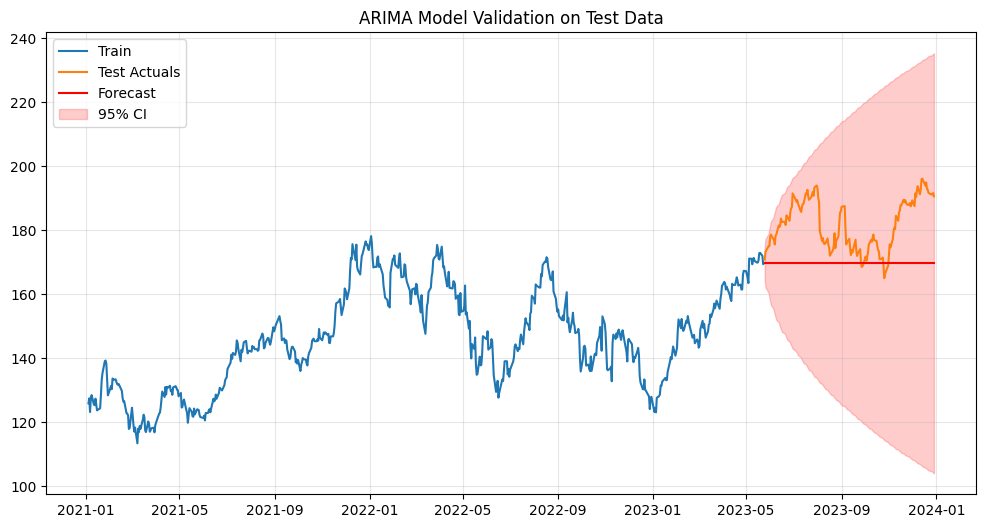

In [19]:
final_model = ARIMA(train_data, order=best_order)
final_results = final_model.fit()

forecast_steps = len(test_data)
forecast_res = final_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

forecast_mean.index = test_data.index
conf_int.index = test_data.index

plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label="Train")
plt.plot(test_data.index, test_data, label="Test Actuals")
plt.plot(forecast_mean.index, forecast_mean, color="red", label="Forecast")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.2, label="95% CI")
plt.title("ARIMA Model Validation on Test Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

We can see that the best forecast result from the model is simply using the most recent known value. The confidence interval widens over time, as the observed values may deviate further and further from the forecast. Too check the accuracy of this simple model we can calculate the RMSE between the model's guess and real values.

In [9]:
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 14.44


The value is not that bad, but we need to remember that our ARIMA model in fact did not tell us anything about the behaviour of the prices. Now we are going to do on this dataset is the residual analysis.

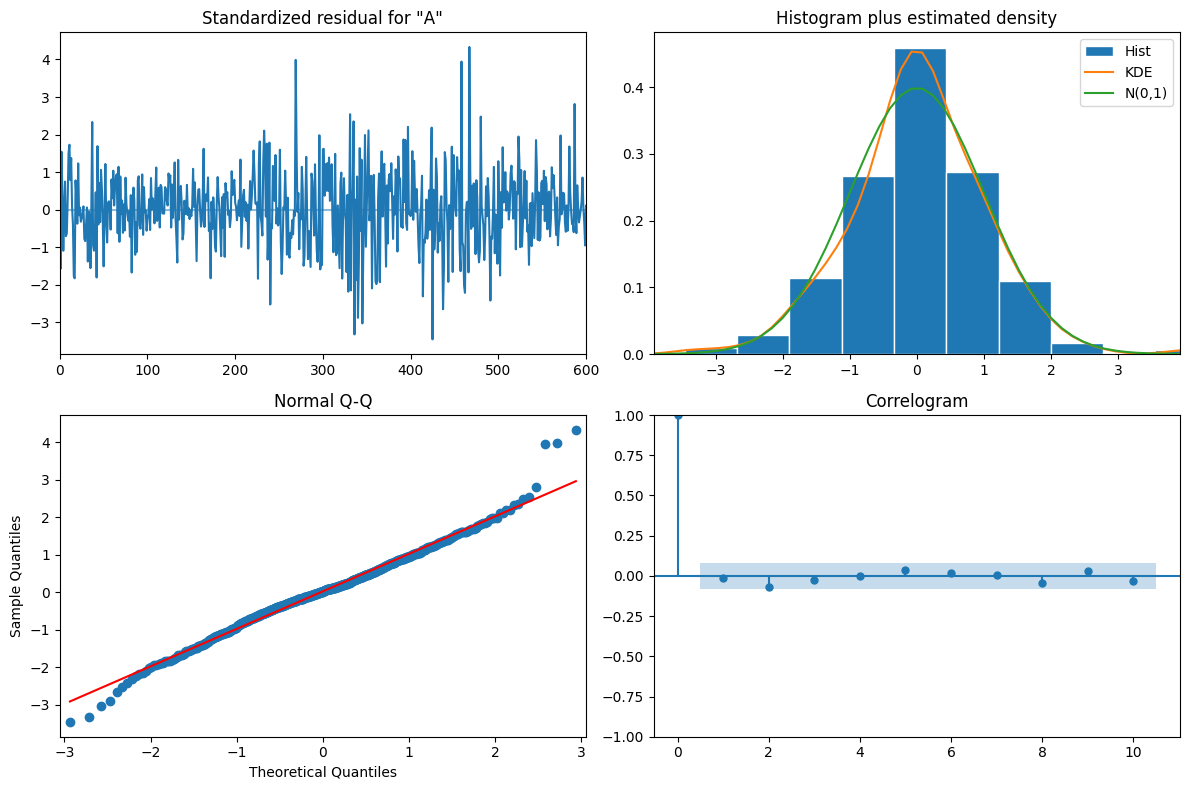

Residuals ADF p-value: 0.0000


In [10]:
fig = final_results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

residuals = final_results.resid
res_adfuller = adfuller(residuals.dropna())
print(f"Residuals ADF p-value: {res_adfuller[1]:.4f}")

Because the residuals fluctuate around zero with no obvious patterns, trends, or seasonality and our p-value is practically zero (well below the standard 0.05 threshold), we reject the null hypothesis. This shows that statistically the residuals are highly stationary. Last thing we are going to do with this particular dataset is visualizing the prediction for the next30 days with the confidence interval.

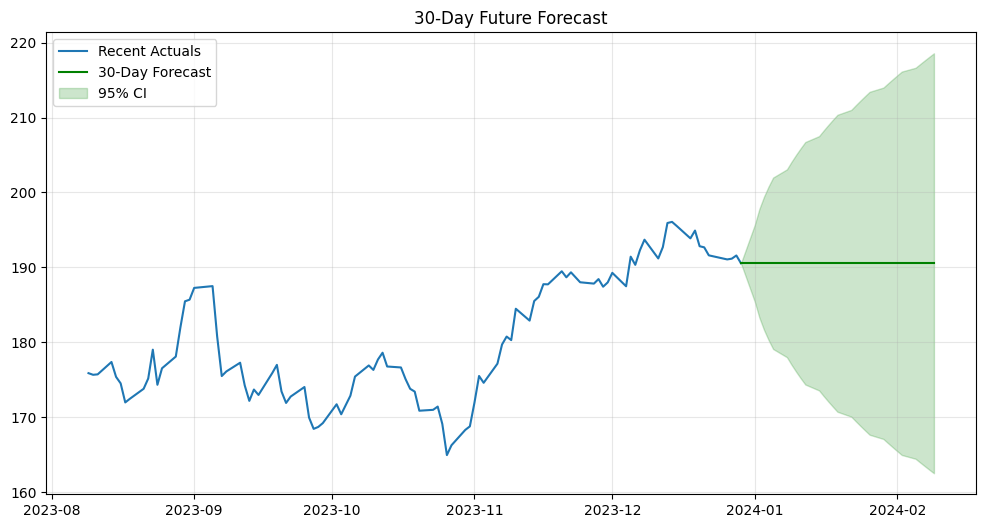

In [20]:
full_model = ARIMA(prices, order=best_order)
full_results = full_model.fit()

future_steps = 30
future_forecast_res = full_results.get_forecast(steps=future_steps)
future_mean = future_forecast_res.predicted_mean
future_conf_int = future_forecast_res.conf_int()

last_date = prices.index[-1]
last_price = prices.iloc[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=future_steps)

future_mean.index = future_dates
future_conf_int.index = future_dates

future_mean_plot = pd.concat([pd.Series({last_date: last_price}), future_mean])
last_conf = pd.DataFrame({future_conf_int.columns[0]: [last_price], future_conf_int.columns[1]: [last_price]}, index=[last_date])
future_conf_int_plot = pd.concat([last_conf, future_conf_int])

plt.figure(figsize=(12, 6))
plt.plot(prices.iloc[-100:].index, prices.iloc[-100:], label="Recent Actuals")
plt.plot(future_mean_plot.index, future_mean_plot, color="green", label="30-Day Forecast")
plt.fill_between(future_conf_int_plot.index, future_conf_int_plot.iloc[:, 0], future_conf_int_plot.iloc[:, 1], color="green", alpha=0.2, label="95% CI")
plt.title("30-Day Future Forecast")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Obviously, the model uses the last known value as a prediction and the confidence interval grows over time. The final conclusion is that for a completely random walk that we can observe in this particular dataset, ARIMA model does not provide any deeper information and cannot magically predict the future. Thus, we repeat the whole procedure for another dataset to show that in fact, time series modelling might be a usefull tool for forecasting.

We will use the VIX. Unlike standard stock prices, volatility is strongly mean-reverting, which means it might pass the stationarity test without differencing and yield a more interesting ARIMA model with autoregressive terms.

[*********************100%***********************]  1 of 1 completed


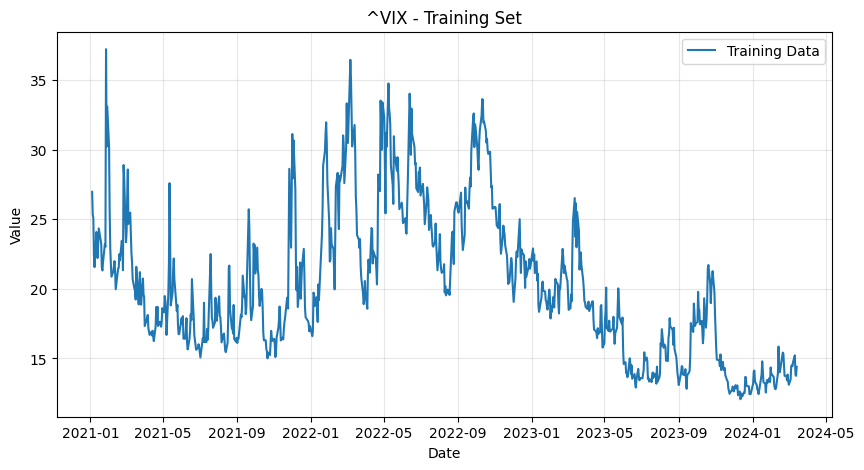

In [35]:
ticker = "^VIX"
data = yf.download(ticker, start="2021-01-01", end="2025-01-01")
prices = data['Close'].dropna()

if isinstance(prices, pd.DataFrame):
    prices = prices.squeeze()

train_size = int(len(prices) * 0.8)
train_data, test_data = prices.iloc[:train_size], prices.iloc[train_size:]

plt.figure(figsize=(10, 5))
plt.plot(train_data, label="Training Data")
plt.title(f"{ticker} - Training Set")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Now we do the stationarity check.

In [36]:
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    return result[1] <= 0.05

is_stationary = check_stationarity(train_data)

d = 0
differenced_data = train_data.copy()

while not is_stationary and d < 3:
    d += 1
    differenced_data = differenced_data.diff().dropna()
    print(f"Testing differenced data (d={d}):")
    is_stationary = check_stationarity(differenced_data)

print(f"Optimal differencing order (d): {d}")

ADF Statistic: -3.7218
p-value: 0.0038
Optimal differencing order (d): 0


As expected, we do not have to differenciate the data. Let's check the ACF and PACF plots.

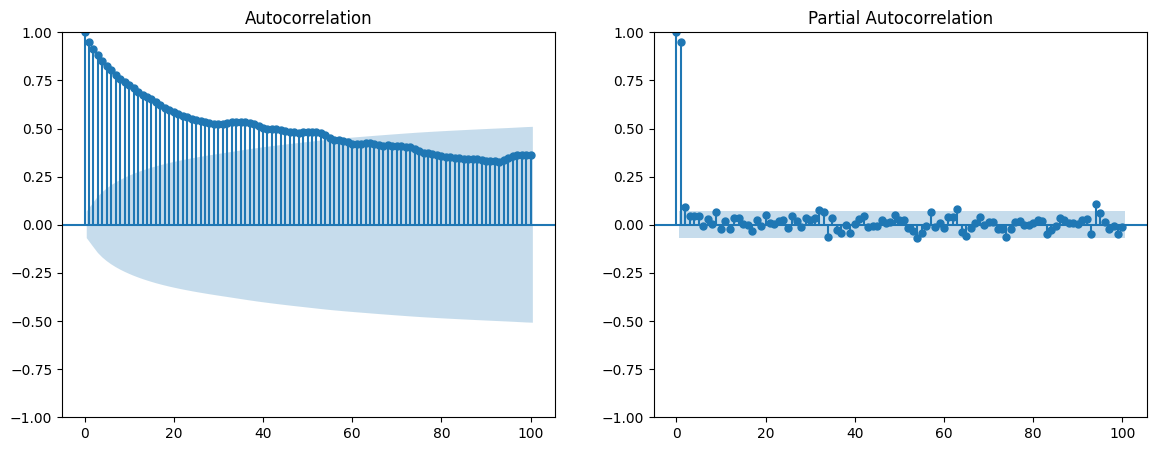

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(differenced_data, ax=axes[0], lags=100)
plot_pacf(differenced_data, ax=axes[1], lags=100)
plt.show()

The autocorrelations decay very slowly over many lags. This gradual, trailing off pattern indicates a highly persistent time series with a strong memory of its past values. On the PACF plot, there is a massive, highly significant spike at lag 1, and a much smaller spike at lag 2. Later there is no significant partial autocorrelation. 

In terms of ARIMA parameters estimation, the drop in the PACF after lag 1 or 2, combined with the slow decay in the ACF, suggests an autoregressive process. Because of that, we can assume that our optimal p parameter should be 1 or 2. Because the ACF does not cut off sharply but instead decays gradually, a moving average parameter should not be especially high. Now, we calculate the parameters with the grid search and AIC citerion.

In [40]:
p_values = range(0, 4)
q_values = range(0, 4)
best_aic = float("inf")
best_order = None

for p, q in itertools.product(p_values, q_values):
    try:
        model = ARIMA(train_data, order=(p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
    except:
        continue

print(f"Best ARIMA Order: {best_order} with AIC: {best_aic:.2f}")

Best ARIMA Order: (2, 0, 2) with AIC: 3049.71


We obtained ARIMA(2,0,2) model. Let's see how well it describes our dataset's behaviour on the test set and is it more accurate than simpler models used as a benchmark.

RMSE Comparison:
                   Model     RMSE
          ARIMA(2, 0, 2) 3.473434
         Historical Mean 5.529547
Last Known Value (Naive) 3.962177


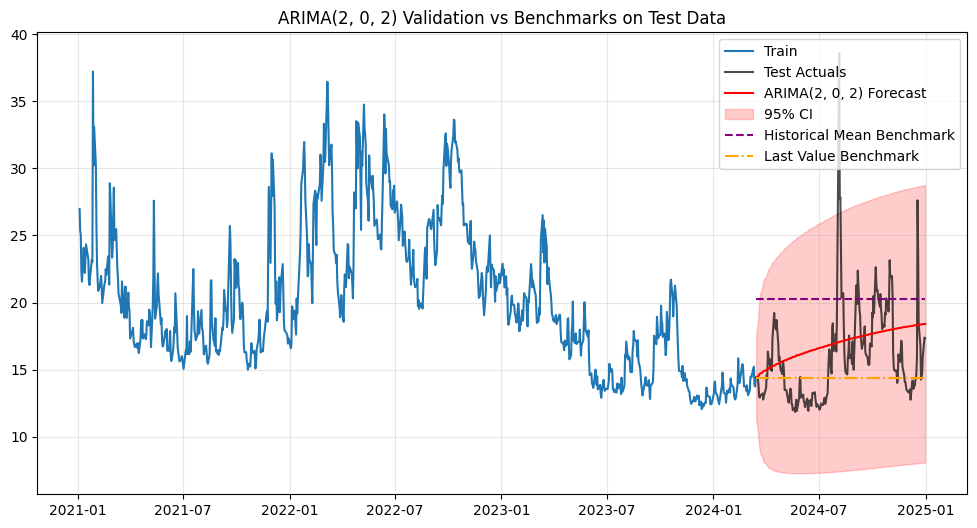

In [41]:
final_model = ARIMA(train_data, order=best_order)
final_results = final_model.fit()

forecast_steps = len(test_data)
forecast_res = final_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

forecast_mean.index = test_data.index
conf_int.index = test_data.index

mean_value = train_data.mean()
last_known_value = train_data.iloc[-1]

mean_forecast = pd.Series(mean_value, index=test_data.index)
naive_forecast = pd.Series(last_known_value, index=test_data.index)

rmse_arima = np.sqrt(mean_squared_error(test_data, forecast_mean))
rmse_mean = np.sqrt(mean_squared_error(test_data, mean_forecast))
rmse_naive = np.sqrt(mean_squared_error(test_data, naive_forecast))
rmse_data = {
    "Model": [f"ARIMA{best_order}", "Historical Mean", "Last Known Value (Naive)"],
    "RMSE": [rmse_arima, rmse_mean, rmse_naive]
}
rmse_df = pd.DataFrame(rmse_data)
print("RMSE Comparison:")
print(rmse_df.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label="Train")
plt.plot(test_data.index, test_data, label="Test Actuals", color="black", alpha=0.7)

plt.plot(forecast_mean.index, forecast_mean, color="red", label=f"ARIMA{best_order} Forecast")
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.2, label="95% CI")

plt.plot(mean_forecast.index, mean_forecast, color="purple", linestyle="--", label="Historical Mean Benchmark")
plt.plot(naive_forecast.index, naive_forecast, color="orange", linestyle="-.", label="Last Value Benchmark")

plt.title(f"ARIMA{best_order} Validation vs Benchmarks on Test Data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Looking at the RMSE values and data behaviour on the plot, we can see that our ARIMA(2,0,2) model worked better as a forecasting tool than two simpler models that we checked - the historical mean value and the last known value. Even unpredicted spike in the data that was outside the confidence interval did not change the fact that ARIMA(2,0,2) was by far the most accurate.

Now let's see the residuals diagnosis.

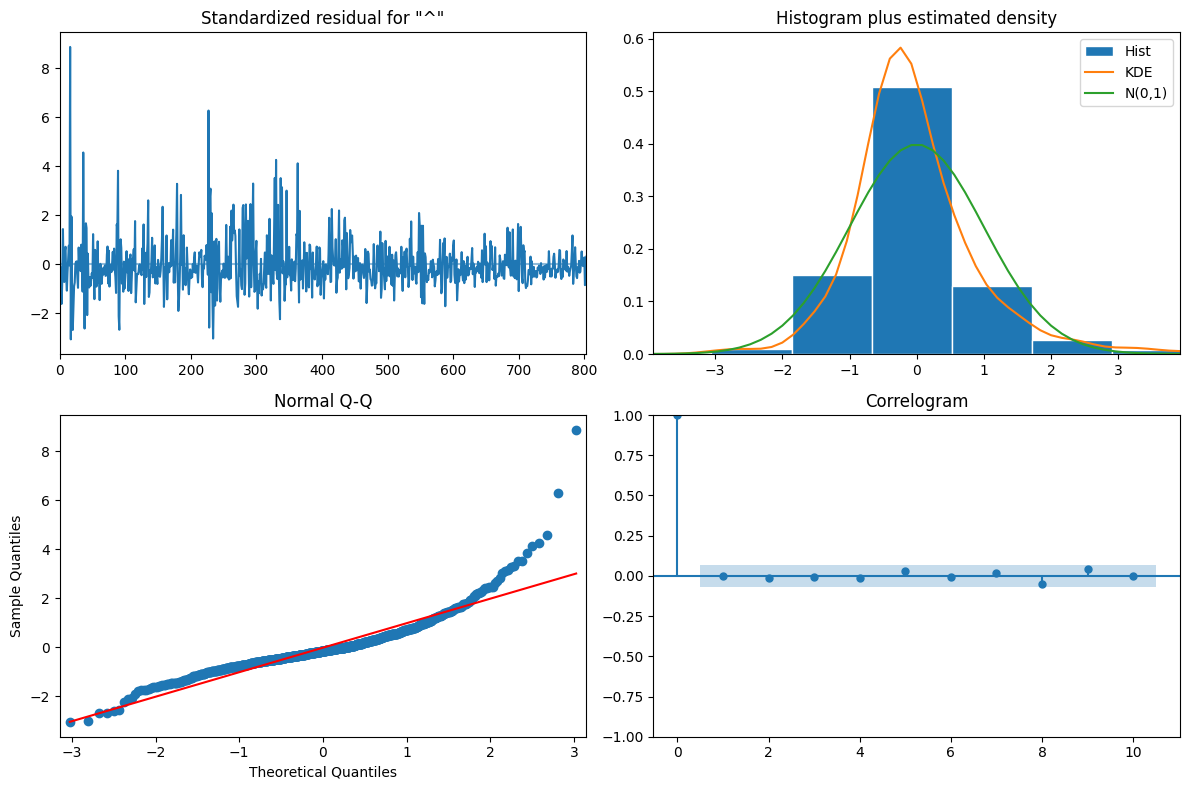

Residuals ADF p-value: 0.0000


In [42]:
fig = final_results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

residuals = final_results.resid
res_adfuller = adfuller(residuals.dropna())
print(f"Residuals ADF p-value: {res_adfuller[1]:.4f}")

Looking at the correlogram we see that the lags after lag 0 are inside the confidence interval. The ARIMA model successfully captured all the time based patterns in the data. With a p-value of 0.0000, the residuals are stationary. However, the Q-Q plot shows massive deviations at the tails. In general, the model did a great job capturing the mean behavior of the VIX. There is no predictable pattern left in the correlogram. However, it failed the assumption of normally distributed, errors with constant variance.

Below we present the forecast for the next 30 days.

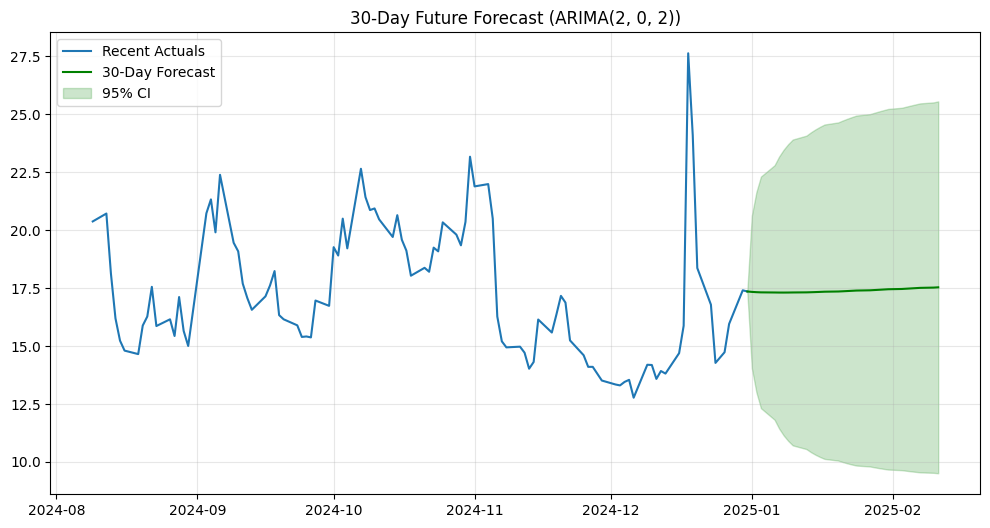

In [44]:
full_model = ARIMA(prices, order=best_order)
full_results = full_model.fit()

future_steps = 30
future_forecast_res = full_results.get_forecast(steps=future_steps)
future_mean = future_forecast_res.predicted_mean
future_conf_int = future_forecast_res.conf_int()

last_date = prices.index[-1]
last_price = prices.iloc[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=future_steps)

future_mean.index = future_dates
future_conf_int.index = future_dates

future_mean_plot = pd.concat([pd.Series({last_date: last_price}), future_mean])
last_conf = pd.DataFrame({future_conf_int.columns[0]: [last_price], future_conf_int.columns[1]: [last_price]}, index=[last_date])
future_conf_int_plot = pd.concat([last_conf, future_conf_int])

plt.figure(figsize=(12, 6))
plt.plot(prices.iloc[-100:].index, prices.iloc[-100:], label="Recent Actuals")
plt.plot(future_mean_plot.index, future_mean_plot, color="green", label="30-Day Forecast")
plt.fill_between(future_conf_int_plot.index, future_conf_int_plot.iloc[:, 0], future_conf_int_plot.iloc[:, 1], color="green", alpha=0.2, label="95% CI")
plt.title(f"30-Day Future Forecast (ARIMA{best_order})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In this particular case, the forecast looks similar to the constant value of the last observed data, but we can see that it behaves a little bit differently and the model predicts a slight growth in the next 30 days.

## Problem 3.4: GARCH for Volatility

### Objective
Model volatility clustering in financial returns.

### Tasks
- calculate daily returns for S&P 500 index.
- fit GARCH(1,1) model to returns.
- forecast volatility for next 20 days.
- validate using realized volatility.

In [97]:
df_sp500 = pd.read_csv("./../datasets/sp500_yfinance.csv")
df_sp500.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,2058.199951,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
1,2015-01-05,2020.579956,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2,2015-01-06,2002.609985,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
3,2015-01-07,2025.900024,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
4,2015-01-08,2062.139893,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


Before applying the GARCH model, the data must be properly formatted.

The date column is converted to datetime format and the adjusted closing price is selected as the primary price series. The adjusted close is preferred because it accounts for corporate actions such as dividends and stock splits.

In [98]:
df_sp500["Date"] = pd.to_datetime(df_sp500["Date"])

df_sp500 = df_sp500[["Date", "Adj Close"]].copy()
df_sp500 = df_sp500.rename(columns={"Adj Close": "Price"})

df_sp500.head()

,Date,Price
0,2015-01-02,2058.199951
1,2015-01-05,2020.579956
2,2015-01-06,2002.609985
3,2015-01-07,2025.900024
4,2015-01-08,2062.139893


lets visualize

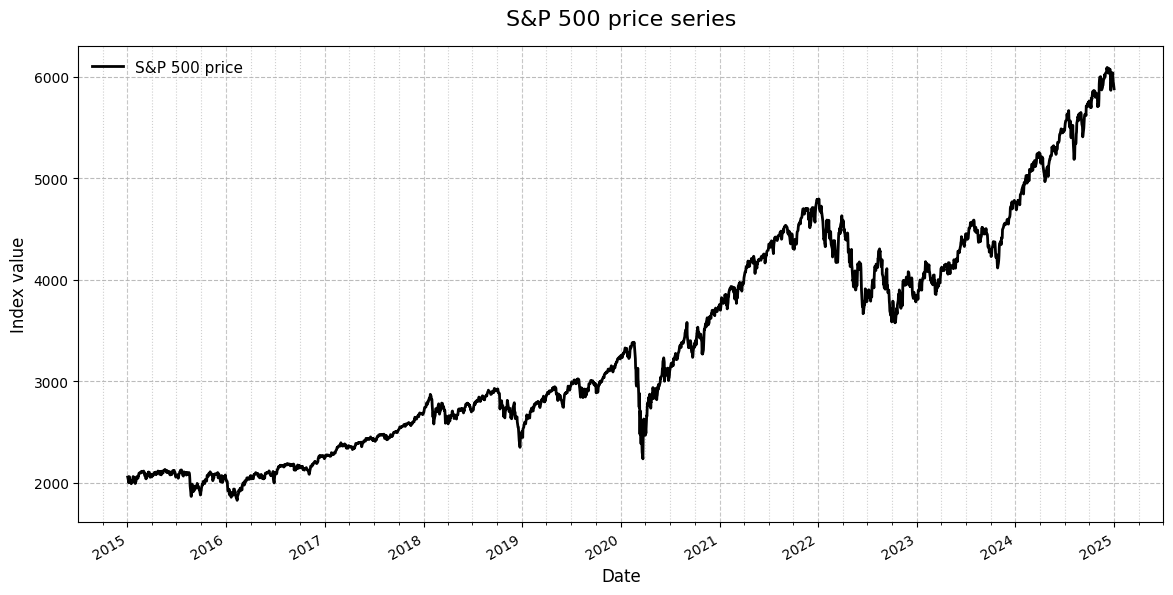

In [99]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_sp500["Date"], df_sp500["Price"], label="S&P 500 price", color="black", linewidth=2)
ax.set_title("S&P 500 price series", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Index value", fontsize=12)

# major ticks every year
# minor ticks every 3 months
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.85)
ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.70)
ax.grid(True, which="minor", axis="x", linestyle=":", alpha=0.60)
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.show()

GARCH models are applied to returns rather than price levels.

Daily log returns are computed as:

$$
r_t = 100 * \log\left(\frac{P_t}{P_{t-1}}\right)
$$

The values are multiplied by 100, so returns are expressed in percentage points. Log returns are commonly used in volatility modeling because they are time-additive and behave well for financial time series.

In [100]:
df_sp500["Return"] = 100 * np.log(df_sp500["Price"] / df_sp500["Price"].shift(1))
df_sp500 = df_sp500.dropna()

df_sp500 = df_sp500.dropna().reset_index(drop=True)
df_sp500.head()

,Date,Price,Return
0,2015-01-05,2020.579956,-1.844721
1,2015-01-06,2002.609985,-0.893325
2,2015-01-07,2025.900024,1.156274
3,2015-01-08,2062.139893,1.773017
4,2015-01-09,2044.810059,-0.843932


lets visualize

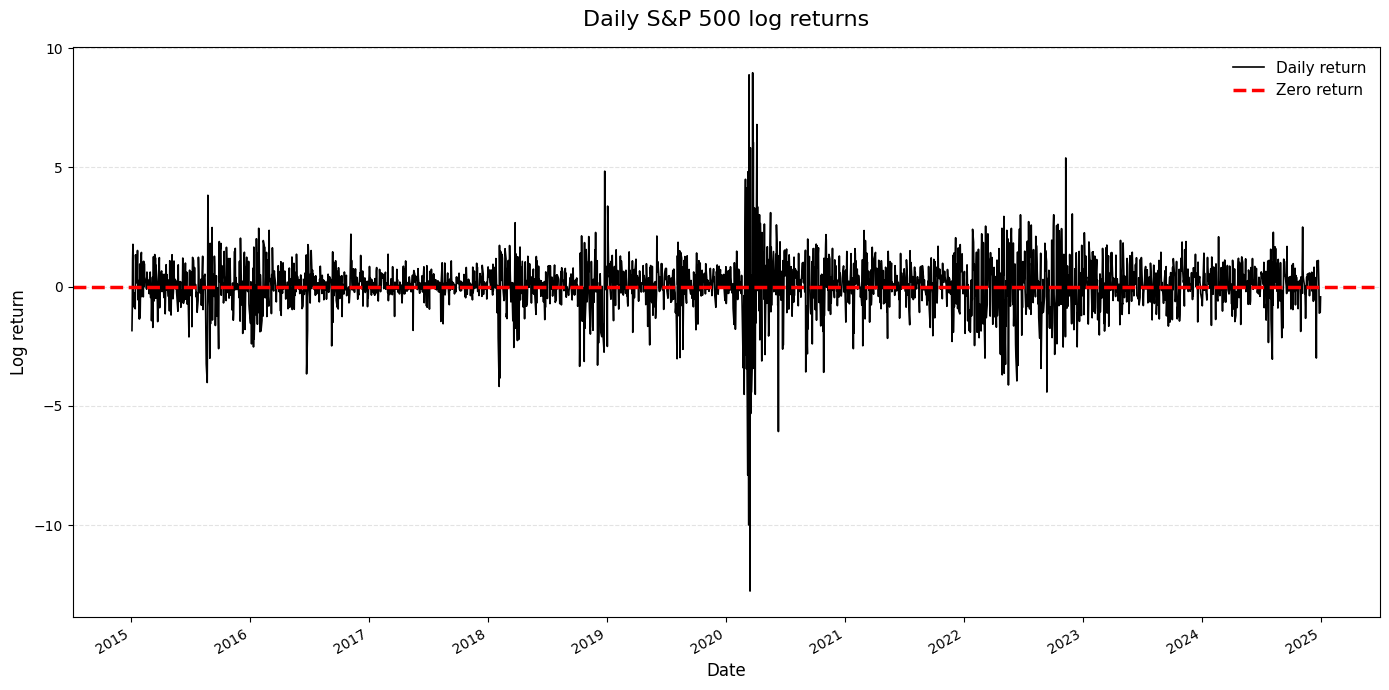

In [110]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_sp500["Date"], df_sp500["Return"], color="black", linewidth=1.2, label="Daily return")
ax.axhline(y=0, color="red", linestyle="--", linewidth=2.5, label="Zero return")
ax.set_title("Daily S&P 500 log returns", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Log return", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Financial return series often exhibit volatility clustering. This means that large changes tend to be followed by large changes, and small changes tend to be followed by small changes. To highlight this effect, absolute returns are analyzed.

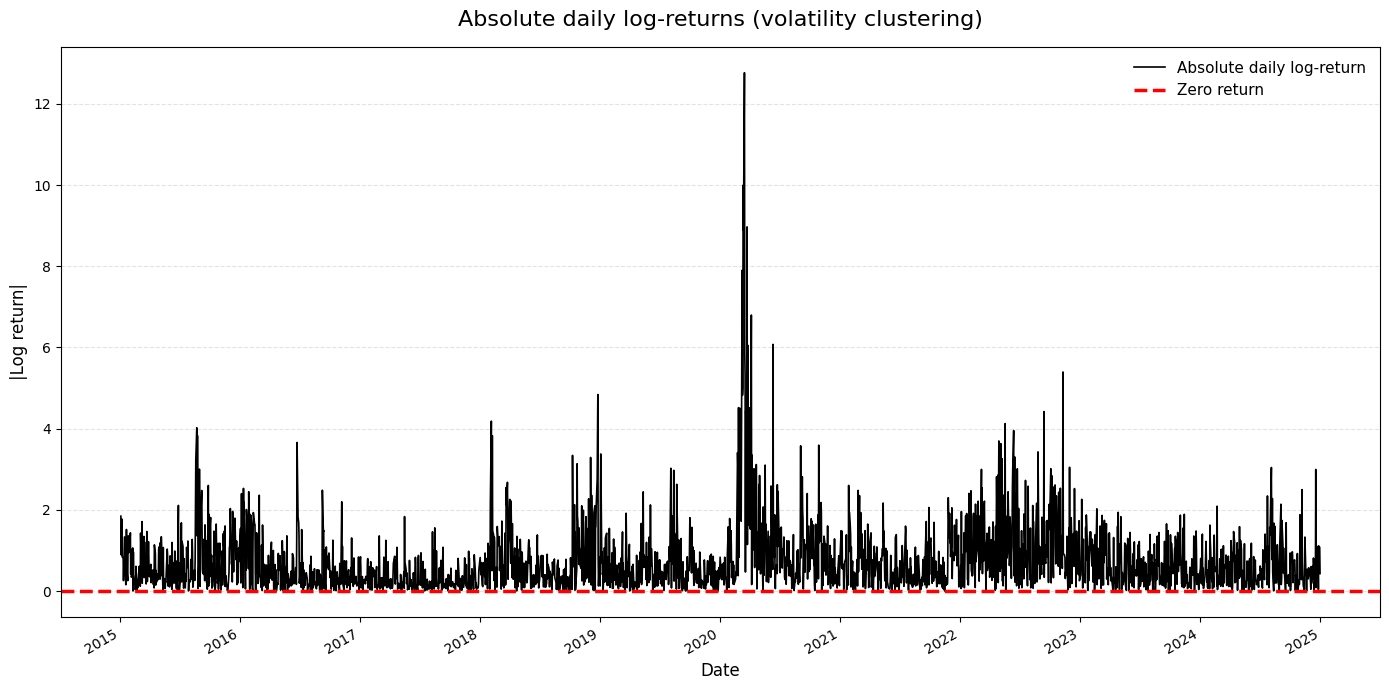

In [113]:
df_sp500["AbsReturn"] = df_sp500["Return"].abs()
# absolute value highlights mggagnitude of returns regardless of direction

fig, ax = plt.subplots(figsize=(14, 7))
plt.plot(df_sp500["Date"], df_sp500["AbsReturn"], color="black", linewidth=1.2, label="Absolute daily log-return")
ax.axhline(y=0, color="red", linestyle="--", linewidth=2.5, label="Zero return")
ax.set_title("Absolute daily log-returns (volatility clustering)", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("|Log return|", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

To evaluate the forecasting performance, the dataset is divided into:
- a training set,
- a test set containing the last 20 observations.

In [103]:
forecast_horizon = 20

train_returns = df_sp500["Return"].iloc[:-forecast_horizon]
test_returns = df_sp500["Return"].iloc[-forecast_horizon:]

train_dates = df_sp500["Date"].iloc[:-forecast_horizon]
test_dates = df_sp500["Date"].iloc[-forecast_horizon:]

Now we fit the GARCH(1,1) model. This is one of the standard models for conditional heteroskedasticity in financial returns. It assumes that current volatility depends on:
- a constant term,
- the squared shock from the previous period,
- the previous conditional variance.

In [104]:
garch_model = arch_model(
    train_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(disp="off")
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3199.82
Distribution:                  Normal   AIC:                           6407.64
Method:            Maximum Likelihood   BIC:                           6430.93
                                        No. Observations:                 2495
Date:                Sun, Apr 26 2026   Df Residuals:                     2494
Time:                        22:15:33   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0807  1.484e-02      5.440  5.314e-08 [5.165e-0

In [114]:
params = garch_result.params

omega = params["omega"]
alpha = params["alpha[1]"]
beta = params["beta[1]"]

print(f"omega: {omega:.6f}")
print(f"alpha[1]: {alpha:.6f}")
print(f"beta[1]: {beta:.6f}")
print(f"alpha[1] + beta[1]: {alpha + beta:.6f}")

omega: 0.037951
alpha[1]: 0.184867
beta[1]: 0.785676
alpha[1] + beta[1]: 0.970543


The estimated coefficients of the GARCH(1,1) model determine how shocks and past volatility affect current variance. In particular:
- **omega** controls the long-run variance level,
- **alpha[1]** measures the impact of recent shocks,
- **beta[1]** measures persistence of volatility over time.

The fitted GARCH(1,1) model shows statistically significant parameters in both the mean and volatility equations. The estimated mean return is positive, but the main focus of this task is the volatility equation rather than the average return. In the volatility equation, all parameters are statistically significant. The estimated value (+-) of $\alpha_1 = 0.2$ measures the short-term reaction of volatility to new shocks. The estimated value of $\beta_1 = 0.8$ measures the persistence of past volatility. Since beta1 is much larger than alpha_1, volatility is mainly driven by persistence rather than only by the most recent shock.

The sum of the two parameters is is close to 1, which indicates strong volatility persistence. In practice, this means that volatility shocks decay slowly over time. The model therefore captures one of the key stylized facts of financial data: periods of high volatility tend to be followed by high volatility, while periods of low volatility tend to be followed by low volatility.

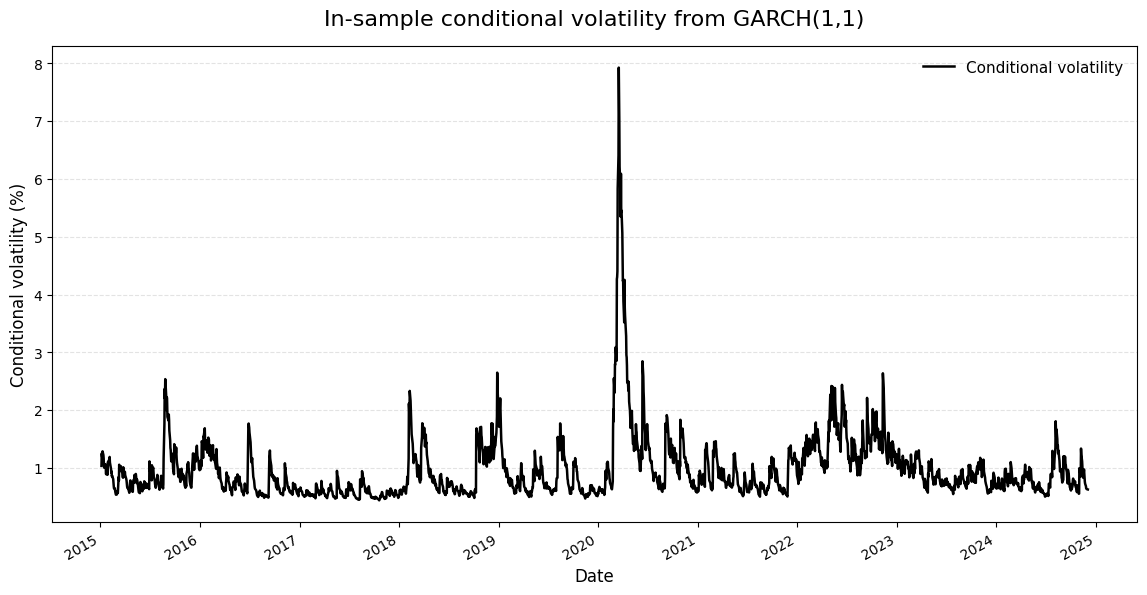

In [105]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_dates, garch_result.conditional_volatility, color="black", linewidth=1.8, label="Conditional volatility")
ax.set_title("In-sample conditional volatility from GARCH(1,1)", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Conditional volatility (%)", fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
fig.autofmt_xdate()
plt.show()

After fitting the GARCH(1,1) model, standardized residuals are analyzed. If the model captures the conditional volatility structure well, standardized residuals should behave approximately like white noise. In particular, there should be no strong autocorrelation left in the residuals or in their squared values.

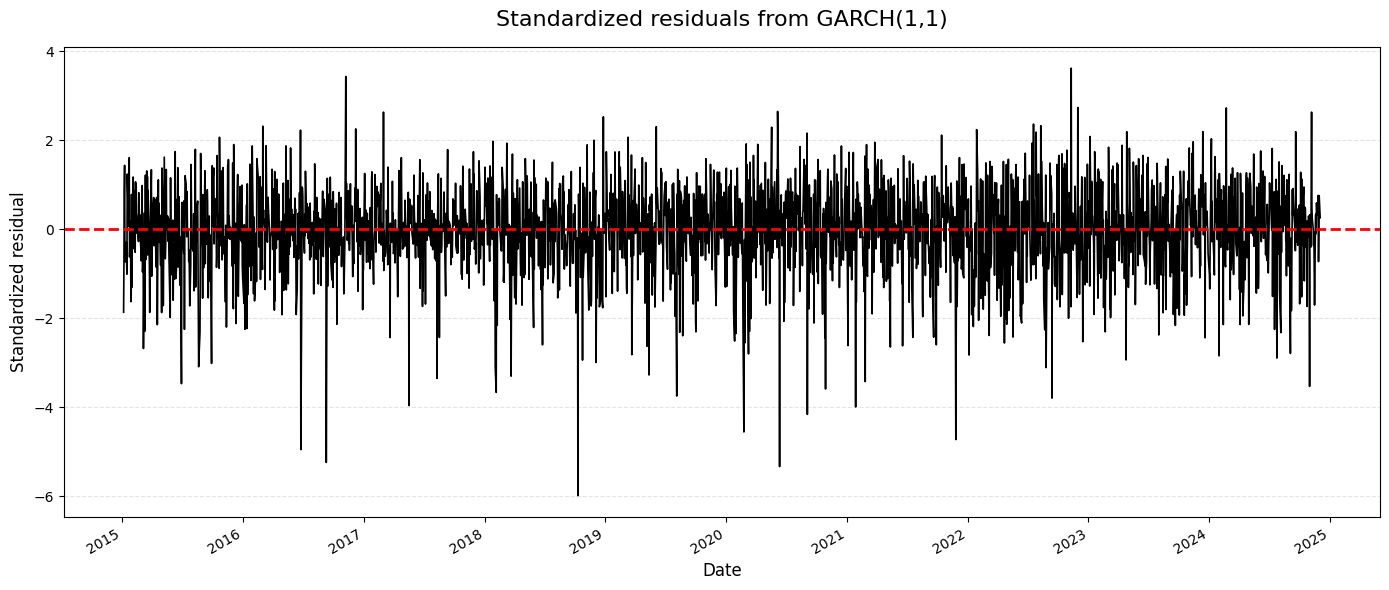

In [115]:
standardized_residuals = pd.Series(
    np.asarray(garch_result.std_resid),
    index=train_dates
).dropna()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(standardized_residuals.index, standardized_residuals.values, color="black", linewidth=1.2)
ax.axhline(0, linestyle="--", color="red", linewidth=2)
ax.set_title("Standardized residuals from GARCH(1,1)", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Standardized residual", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The standardized residuals fluctuate around zero and do not show a clear trend over time. There are several large negative and positive observations.

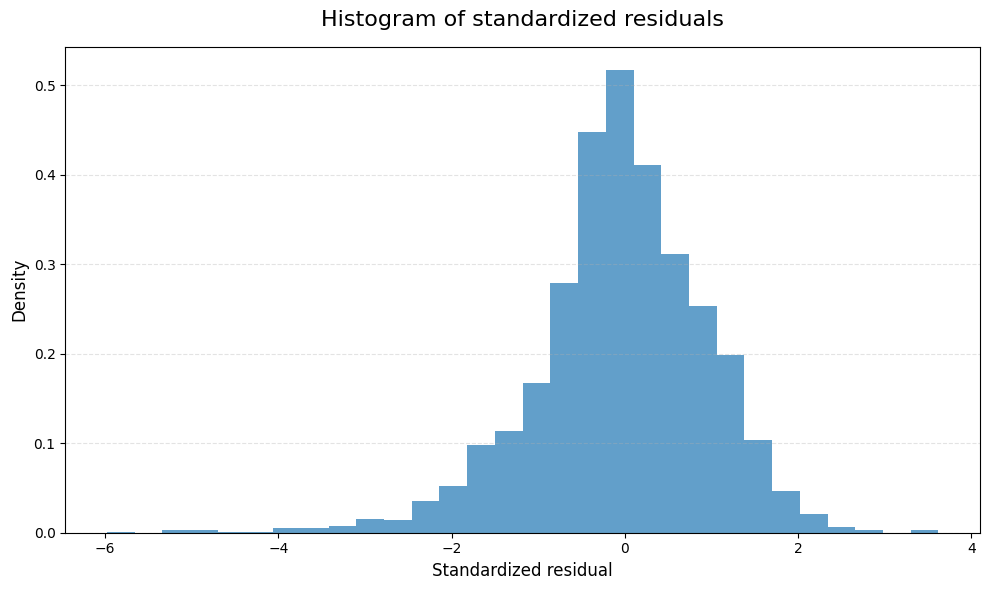

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(standardized_residuals.values, bins=30, density=True, alpha=0.7)
ax.set_title("Histogram of standardized residuals", fontsize=16, pad=15)
ax.set_xlabel("Standardized residual", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

The histogram is centered close to zero, but it has visible tails and outliers.

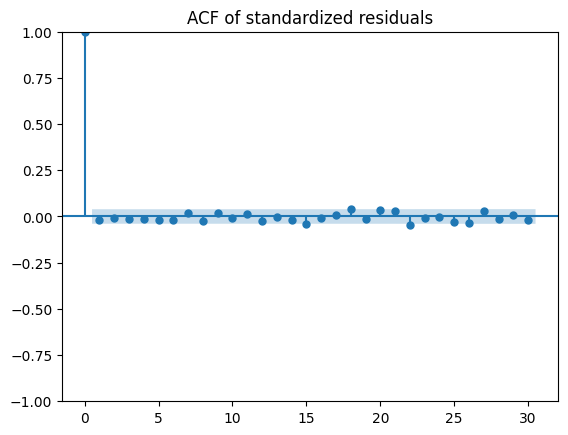

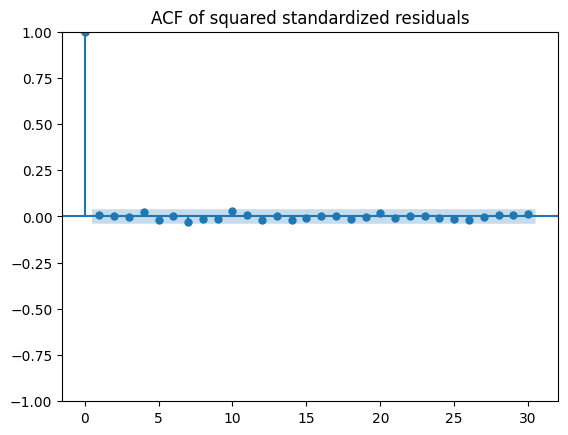

In [117]:
plot_acf(standardized_residuals.values, lags=30)
plt.title("ACF of standardized residuals")
plt.show()

plot_acf(standardized_residuals.values ** 2, lags=30)
plt.title("ACF of squared standardized residuals")
plt.show()

The ACF of standardized residuals does not show strong autocorrelation. This means that the model removed most of the linear dependence from the return series. The ACF of squared standardized residuals is also close to zero for most lags.

Overall, the residual diagnostics support the fitted GARCH model. The model is not perfect, especially because of extreme observations, but it removes the main volatility dependence that was present in the raw return series. Now lets forecast 20 days test set.

In [106]:
garch_forecast = garch_result.forecast(horizon=forecast_horizon)
forecast_variance = garch_forecast.variance.iloc[-1].values
# .iloc[-1] selects the final forecast origin
# .values extracts the forecasted variances for all forecast horizons

forecast_volatility = np.sqrt(forecast_variance)
# volatility is the square root of variance

forecast_volatility

array([0.59256558, 0.61542001, 0.63681736, 0.65691826, 0.67585562,
       0.69374098, 0.71066918, 0.72672175, 0.74196943, 0.75647411,
       0.77029039, 0.78346673, 0.79604639, 0.80806825, 0.81956736,
       0.83057551, 0.84112164, 0.85123217, 0.86093134, 0.87024143])

To validate the forecasts, realized volatility is approximated using the absolute value of daily log returns in the test period:

$$
\sigma_t^{realized} \approx |r_t|
$$

This is a simple realized volatility proxy. Large absolute log returns correspond to high realized volatility.

In [107]:
realized_volatility = test_returns.abs().values
# use absolute returns as a simple realized volatility proxy

validation_df = pd.DataFrame({
    "Date": test_dates.values,
    "Forecasted volatility": forecast_volatility,
    "Realized volatility": realized_volatility
})

validation_df.head()

,Date,Forecasted volatility,Realized volatility
0,2024-12-03,0.592566,0.045135
1,2024-12-04,0.615420,0.603318
2,2024-12-05,0.636817,0.187153
3,2024-12-06,0.656918,0.249235
4,2024-12-09,0.675856,0.616317


And finally, plot below compares the 20-day GARCH forecast with realized volatility observed in the test set.

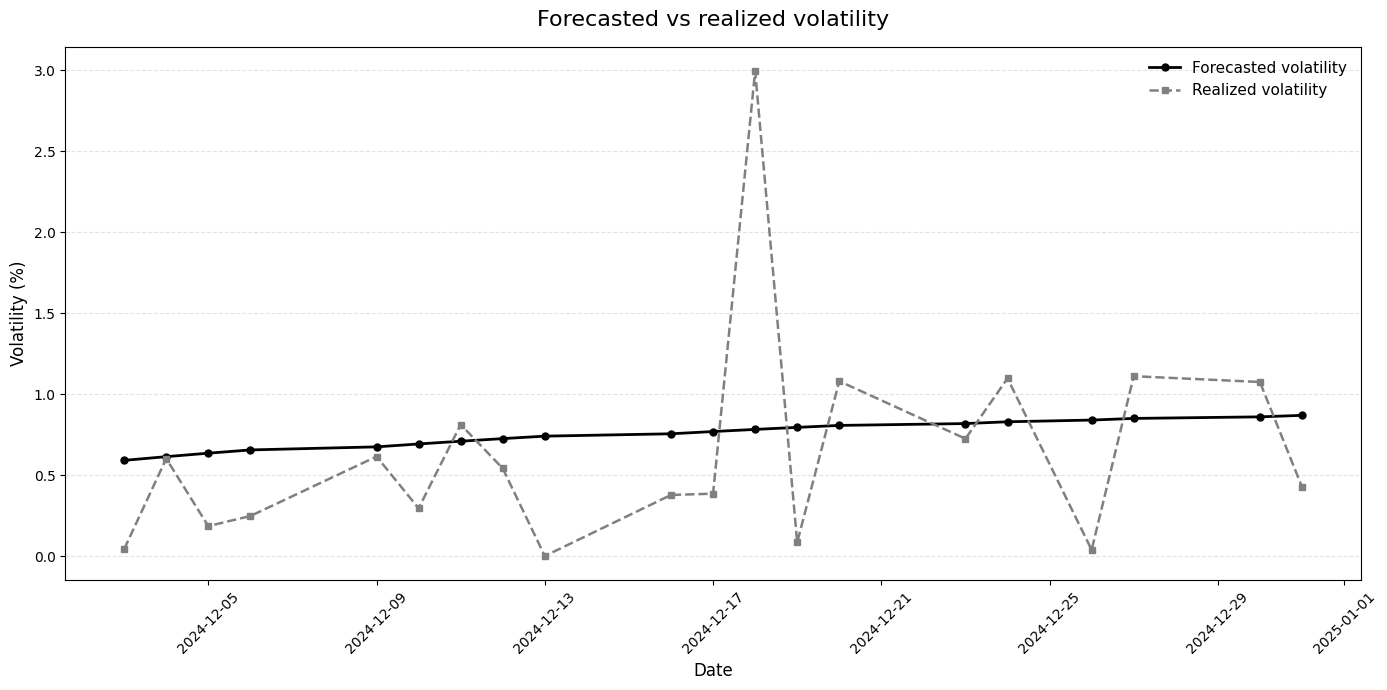

In [108]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(validation_df["Date"],validation_df["Forecasted volatility"],label="Forecasted volatility",color="black",linewidth=2,marker="o",markersize=5)
ax.plot(validation_df["Date"],validation_df["Realized volatility"],label="Realized volatility",color="gray",linewidth=1.8,linestyle="--",marker="s",markersize=4)
ax.set_title("Forecasted vs realized volatility", fontsize=16, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Volatility (%)", fontsize=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")
ax.legend(frameon=False, fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The forecasted volatility follows a smooth trajectory, while the realized volatility proxy is much more irregular. This is expected because GARCH forecasts the conditional standard deviation, whereas realized volatility measured by absolute daily log returns is noisy and can change sharply from one day to another. Large one-day movements in realized volatility are not expected to be predicted exactly by the model. The GARCH(1,1) model reacts to volatility clustering and persistence, but it cannot anticipate sudden market shocks before they occur.

In addition to visual comparison, a simple error metric can be computed to summarize forecast quality. We will use MAE

In [109]:
mae_volatility = np.mean(np.abs(validation_df["Forecasted volatility"] - validation_df["Realized volatility"]))
print("MAE:", mae_volatility)

MAE: 0.4465106297344562


The Mean Absolute Error (MAE) indicates a noticeable discrepancy between predicted and realized volatility. This error is largely driven by extreme values in the realized volatility, which significantly exceed the smooth forecasts produced by the model. As a result, the model tends to underestimate volatility during periods of sudden market stress.

Therefore, the relatively high MAE reflects both model limitations and the inherently unpredictable nature of financial markets.